# Q-factorisation on Gridworld Maze

In [ ]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, EarlyStopperRL, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, compute_weight_change_from_snapshots, plot_sa_encoder_changes_across_tasks)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss, contrastive_loss
from networks import snapshot_named_parameters


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


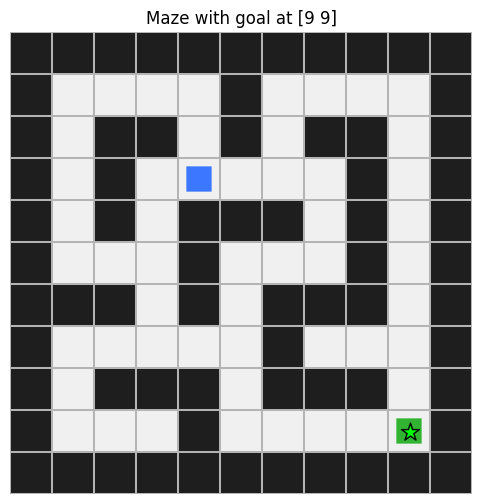

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=100):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FactorisedDQN_QNetwork(nn.Module):
    def __init__(
        self,
        obs_dim: int,
        num_actions: int,
        goal_dim: int,
        hidden_dim: int = 128,
        rep_dim: int = 64,
        q_hidden_dim: int = 128,
        normalize_embeddings: bool = True,
    ):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.action_dim = num_actions
        self.goal_dim = goal_dim
        self.hidden_dim = hidden_dim
        self.rep_dim = rep_dim
        self.q_hidden_dim = q_hidden_dim
        self.normalize_embeddings = normalize_embeddings

        self.sa_encoder = nn.Sequential(
            nn.Linear(obs_dim + num_actions, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.goal_encoder = nn.Sequential(
            nn.Linear(goal_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

        self.q_head = nn.Sequential(
            nn.Linear(2 * rep_dim, q_hidden_dim),
            nn.ReLU(),
            nn.Linear(q_hidden_dim, 1),
        )

    def encode_state_action(self, obs: torch.Tensor, act_onehot: torch.Tensor) -> torch.Tensor:
        x = torch.cat([obs, act_onehot], dim=-1)
        z = self.sa_encoder(x)
        if self.normalize_embeddings:
            z = F.normalize(z, dim=-1)
        return z

    def encode_goal(self, goal: torch.Tensor) -> torch.Tensor:
        z = self.goal_encoder(goal)
        if self.normalize_embeddings:
            z = F.normalize(z, dim=-1)
        return z

    def q_from_embeddings(self, phi: torch.Tensor, psi: torch.Tensor) -> torch.Tensor:
        x = torch.cat([phi, psi], dim=-1)
        return self.q_head(x)

    def q_values_from_state_goal(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        """
        obs:  [B, obs_dim]
        goal: [B, goal_dim]
        returns: [B, num_actions]
        """
        B = obs.shape[0]
        device = obs.device

        psi = self.encode_goal(goal)  # [B, rep_dim]

        act_eye = torch.eye(self.num_actions, device=device).unsqueeze(0).expand(B, -1, -1)
        obs_rep = obs.unsqueeze(1).expand(-1, self.num_actions, -1)

        obs_flat = obs_rep.reshape(B * self.num_actions, self.obs_dim)
        act_flat = act_eye.reshape(B * self.num_actions, self.num_actions)
        phi_flat = self.encode_state_action(obs_flat, act_flat)  # [B*A, rep_dim]

        psi_rep = psi.unsqueeze(1).expand(-1, self.num_actions, -1).reshape(B * self.num_actions, self.rep_dim)

        q_flat = self.q_from_embeddings(phi_flat, psi_rep)  # [B*A, 1]
        q_vals = q_flat.view(B, self.num_actions)
        return q_vals

    def q_val_for_argmax_action(self, obs: torch.Tensor, goal: torch.Tensor) -> torch.Tensor:
        return self.q_values_from_state_goal(obs, goal)

    def q_val_for_argmax_action_from_embedding(
        self,
        obs: torch.Tensor,
        task_embedding: torch.Tensor,
        normalize_embedding: bool = False,
    ) -> torch.Tensor:
        """
        Compute Q-values for all actions using a provided task embedding.

        obs: [B, obs_dim]
        task_embedding: [B, rep_dim] or [rep_dim]
        returns: [B, A]
        """
        B = obs.shape[0]
        A = self.num_actions

        act_onehot = F.one_hot(
            torch.arange(A, device=obs.device),
            num_classes=self.action_dim
        ).float()                                             # [A, A]
        act_onehot = act_onehot.unsqueeze(0).expand(B, -1, -1)  # [B, A, A]

        obs_rep = obs.unsqueeze(1).expand(-1, A, -1)          # [B, A, obs_dim]
        obs_flat = obs_rep.reshape(B * A, self.obs_dim)       # [B*A, obs_dim]
        act_flat = act_onehot.reshape(B * A, self.action_dim) # [B*A, A]

        phi_sa = self.encode_state_action(obs_flat, act_flat) # [B*A, D]
        phi_sa = phi_sa.view(B, A, self.rep_dim)              # [B, A, D]

        if task_embedding.dim() == 1:
            task_embedding = task_embedding.unsqueeze(0).expand(B, -1)

        psi_z = (
            F.normalize(task_embedding, p=2, dim=-1, eps=1e-8)
            if normalize_embedding
            else task_embedding
        )

        psi_rep = psi_z.unsqueeze(1).expand(B, A, -1)         # [B, A, D]
        q_vals = (phi_sa * psi_rep).sum(dim=-1)               # [B, A]
        return q_vals

class NextStateEncoder(nn.Module):
    def __init__(self, obs_dim: int, hidden_dim: int = 128, rep_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, rep_dim),
        )

    def forward(self, next_obs: torch.Tensor) -> torch.Tensor:
        z = self.net(next_obs)
        z = F.normalize(z, dim=-1)
        return z

In [4]:
class EWCState:
    def __init__(self):
        self.ref_params_sa = None
        self.fisher_sa = None
        self.ref_params_ns = None
        self.fisher_ns = None

def compute_ewc_fisher_for_task(
    q_network,
    next_state_encoder,
    replay_buffer,
    goal,
    num_actions,
    device,
    num_batches: int = 50,
    batch_size: int = 256,
    gamma: float = 0.99,
    temperature: float = 0.05,
    contrastive_reg_coef: float = 0.0,
    sigreg_coef: float = 0.0,
    dyn_coef: float = 1.0,
    fisher_on: str = "dynamics",  # "dynamics" or "td"
):
    q_network.eval()
    next_state_encoder.eval()

    fisher_sa = {
        name: torch.zeros_like(p, device=device)
        for name, p in q_network.sa_encoder.named_parameters()
    }
    fisher_ns = {
        name: torch.zeros_like(p, device=device)
        for name, p in next_state_encoder.named_parameters()
    }

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    for _ in range(num_batches):
        batch = replay_buffer.sample(batch_size)

        obs_t = batch.obs
        act_t = batch.actions.long()
        rew_t = batch.rewards
        next_obs_t = batch.next_obs
        term_t = batch.terminated.float()
        trunc_t = batch.truncated.float()

        done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)
        if done_t.ndim == 1:
            done_t = done_t.unsqueeze(-1)
        if rew_t.ndim == 1:
            rew_t = rew_t.unsqueeze(-1)

        B = obs_t.shape[0]
        goal_batch = goal_t_single.expand(B, -1)

        act_onehot = F.one_hot(
            act_t.squeeze(-1),
            num_classes=num_actions
        ).float()

        q_network.zero_grad(set_to_none=True)
        next_state_encoder.zero_grad(set_to_none=True)

        if fisher_on == "dynamics":
            z_sa = q_network.encode_state_action(obs_t, act_onehot)
            z_s_prime = next_state_encoder(next_obs_t)

            logits = z_sa @ z_s_prime.T
            loss = contrastive_loss(
                logits,
                temperature=temperature,
                reg_coef=contrastive_reg_coef,
            )

            if sigreg_coef > 0.0:
                loss = dyn_coef * loss + sigreg_coef * sigreg_loss(z_sa)
            else:
                loss = dyn_coef * loss

        elif fisher_on == "td":
            phi_td = q_network.encode_state_action(obs_t, act_onehot)
            psi_g = q_network.encode_goal(goal_batch)
            current_q = q_network.q_from_embeddings(phi_td, psi_g)

            with torch.no_grad():
                next_q_vals = q_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                next_q = next_q_vals.max(dim=-1, keepdim=True).values
                target = rew_t + gamma * (1.0 - done_t) * next_q

            loss = F.mse_loss(current_q, target)

        else:
            raise ValueError(f"Unknown fisher_on={fisher_on}")

        loss.backward()

        for name, p in q_network.sa_encoder.named_parameters():
            if p.grad is not None:
                fisher_sa[name] += p.grad.detach().pow(2)

        for name, p in next_state_encoder.named_parameters():
            if p.grad is not None:
                fisher_ns[name] += p.grad.detach().pow(2)

    for name in fisher_sa:
        fisher_sa[name] /= float(num_batches)
    for name in fisher_ns:
        fisher_ns[name] /= float(num_batches)

    ref_params_sa = {
        name: p.detach().clone()
        for name, p in q_network.sa_encoder.named_parameters()
    }
    ref_params_ns = {
        name: p.detach().clone()
        for name, p in next_state_encoder.named_parameters()
    }

    q_network.train()
    next_state_encoder.train()

    return ref_params_sa, fisher_sa, ref_params_ns, fisher_ns

In [ ]:
def dqn_train_mlp_head_online(
    seed: int = 42,
    q_network=None,
    q_target_network=None,
    env=None,
    buffer_capacity=None,
    obs_dim=None,
    device=None,
    total_steps=100000,
    warmup_steps=5000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=50000,
    train_freq=4,
    goal=None,
    td_steps=1,
    make_env=None,
    epsilon_reduction=False,
    eps_start_transfer=0.5,
    eps_end_transfer=0.05,
    eps_decay_steps_transfer=20000,
    lr_sa=1e-3,
    lr_ns=1e-3,
    lr_td=1e-3,
    next_state_encoder=None,
    temperature=0.05,
    contrastive_reg_coef=0.0,
    sigreg_coef=0.0,
    dyn_coef=1.0,
    freeze_sa_encoder=False,
    ewc_state=None,
    ewc_lambda_sa=0.0,
    ewc_lambda_ns=0.0,
    early_stop_reward=0.99,
    enable_early_stop=True,
    eval_every=1000,
    eval_episodes=16,
    es_ma_window=5,
    es_plateau_patience=8,
    es_min_improvement=0.01,
    es_max_return_var=0.05,
    es_max_epsilon_for_stop=0.30,
    es_min_decay_progress=0.60,

):
    if q_network is None:
        raise ValueError("q_network must be provided")
    if q_target_network is None:
        raise ValueError("q_target_network must be provided")
    if env is None:
        raise ValueError("env must be provided")
    if buffer_capacity is None:
        raise ValueError("buffer_capacity must be provided")
    if goal is None:
        raise ValueError("goal must be provided")
    if make_env is None:
        raise ValueError("make_env must be provided")

    if device is None:
        device = next(q_network.parameters()).device

    if obs_dim is None:
        obs_dim = int(env.observation_space.shape[0])

    set_seed(seed)

    num_actions = env.action_space.n

    if not freeze_sa_encoder:
        if next_state_encoder is None:
            raise ValueError("next_state_encoder must be provided when freeze_sa_encoder=False")
        opt_dyn = optim.Adam([
            {"params": q_network.sa_encoder.parameters(), "lr": lr_sa},
            {"params": next_state_encoder.parameters(), "lr": lr_ns},
        ])
    else:
        for p in q_network.sa_encoder.parameters():
            p.requires_grad_(False)
        for p in q_target_network.sa_encoder.parameters():
            p.requires_grad_(False)
        opt_dyn = None

    opt_td = optim.Adam([
        {"params": q_network.goal_encoder.parameters(), "lr": lr_td},
        {"params": q_network.q_head.parameters(), "lr": lr_td},
    ])

    buffer = TrajectoryReplayBufferDiscrete(buffer_capacity, obs_dim, 1, device=device)

    goal_arr = np.array(goal, dtype=np.float32)
    goal_t_single = torch.tensor(goal_arr, dtype=torch.float32, device=device).unsqueeze(0)

    obs, _ = env.reset()
    global_step = 0
    eval_returns = []
    eval_returns_time = []
    start_time = time.perf_counter()
    min_steps = None
    min_time = None

    active_decay_steps = eps_decay_steps_transfer if epsilon_reduction else eps_decay_steps
    min_steps_before_stop = int(es_min_decay_progress * active_decay_steps)

    early_stopper = EarlyStopperRL(
        target_reward=early_stop_reward,
        ma_window=es_ma_window,
        plateau_patience=es_plateau_patience,
        min_improvement=es_min_improvement,
        max_return_var=es_max_return_var,
        min_steps_before_stop=min_steps_before_stop,
        max_epsilon_for_stop=es_max_epsilon_for_stop,
    )

    contrastive_loss_val = torch.tensor(0.0, device=device)
    sigreg_loss_val = torch.tensor(0.0, device=device)
    dyn_total_loss = torch.tensor(0.0, device=device)
    td_loss = torch.tensor(0.0, device=device)
    ewc_sa_loss_val = torch.tensor(0.0, device=device)
    ewc_ns_loss_val = torch.tensor(0.0, device=device)
    all_logits = None

    q_network.train()
    q_target_network.train()
    if next_state_encoder is not None:
        next_state_encoder.train()

    while global_step < total_steps:
        if epsilon_reduction:
            frac = min(1.0, global_step / eps_decay_steps_transfer)
            eps = eps_start_transfer + frac * (eps_end_transfer - eps_start_transfer)
        else:
            frac = min(1.0, global_step / eps_decay_steps)
            eps = eps_start + frac * (eps_end - eps_start)

        if np.random.random() < eps:
            action = env.action_space.sample()
        else:
            obs_t_single = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                q_vals = q_network.q_val_for_argmax_action(obs_t_single, goal_t_single)
                action = int(q_vals.argmax(dim=-1).item())

        next_obs, rew, term, trunc, _ = env.step(action)
        done = term or trunc

        buffer.add_transition(obs, action, rew, next_obs, done)
        obs = next_obs
        global_step += 1

        if done:
            obs, _ = env.reset()

        if len(buffer) >= warmup_steps:
            batch = buffer.sample(batch_size)

            obs_t = batch.obs
            act_t = batch.actions.long()
            rew_t = batch.rewards
            next_obs_t = batch.next_obs
            term_t = batch.terminated.float()
            trunc_t = batch.truncated.float()

            done_t = torch.clamp(term_t + trunc_t, 0.0, 1.0)
            if done_t.ndim == 1:
                done_t = done_t.unsqueeze(-1)
            if rew_t.ndim == 1:
                rew_t = rew_t.unsqueeze(-1)

            B = obs_t.shape[0]
            goal_batch = goal_t_single.expand(B, -1)

            act_onehot = F.one_hot(
                act_t.squeeze(-1),
                num_classes=num_actions
            ).float()

            # --------------------------------------------
            # 1) DYNAMICS UPDATE (task 1 only)
            # --------------------------------------------
            if not freeze_sa_encoder:
                z_sa = q_network.encode_state_action(obs_t, act_onehot)
                z_s_prime = next_state_encoder(next_obs_t)

                all_logits = z_sa @ z_s_prime.T

                contrastive_loss_val = contrastive_loss(
                    all_logits,
                    temperature=temperature,
                    reg_coef=contrastive_reg_coef,
                )

                if sigreg_coef > 0.0:
                    sigreg_loss_val = sigreg_loss(z_sa)
                else:
                    sigreg_loss_val = torch.tensor(0.0, device=device)

                dyn_total_loss = dyn_coef * contrastive_loss_val + sigreg_coef * sigreg_loss_val

                if ewc_state is not None:
                    if (
                        ewc_lambda_sa > 0.0
                        and ewc_state.ref_params_sa is not None
                        and ewc_state.fisher_sa is not None
                    ):
                        ewc_sa_loss_val = ewc_regulariser_loss(
                            q_network.sa_encoder,
                            ewc_state.ref_params_sa,
                            ewc_state.fisher_sa,
                        )
                        dyn_total_loss = dyn_total_loss + ewc_lambda_sa * ewc_sa_loss_val

                    if (
                        ewc_lambda_ns > 0.0
                        and ewc_state.ref_params_ns is not None
                        and ewc_state.fisher_ns is not None
                    ):
                        ewc_ns_loss_val = ewc_regulariser_loss(
                            next_state_encoder,
                            ewc_state.ref_params_ns,
                            ewc_state.fisher_ns,
                        )
                        dyn_total_loss = dyn_total_loss + ewc_lambda_ns * ewc_ns_loss_val

                opt_dyn.zero_grad(set_to_none=True)
                dyn_total_loss.backward()
                nn.utils.clip_grad_norm_(q_network.sa_encoder.parameters(), 10.0)
                nn.utils.clip_grad_norm_(next_state_encoder.parameters(), 10.0)
                opt_dyn.step()
            else:
                contrastive_loss_val = torch.tensor(0.0, device=device)
                sigreg_loss_val = torch.tensor(0.0, device=device)
                dyn_total_loss = torch.tensor(0.0, device=device)
                ewc_sa_loss_val = torch.tensor(0.0, device=device)
                ewc_ns_loss_val = torch.tensor(0.0, device=device)


            # --------------------------------------------
            # 2) TD UPDATE
            # --------------------------------------------
            if global_step % train_freq == 0:

                with torch.no_grad():
                    phi_td = q_network.encode_state_action(obs_t, act_onehot)

                psi_g = q_network.encode_goal(goal_batch)
                current_q = q_network.q_from_embeddings(phi_td, psi_g)

                with torch.no_grad():
                    next_q_vals = q_target_network.q_val_for_argmax_action(next_obs_t, goal_batch)
                    next_q = next_q_vals.max(dim=-1, keepdim=True).values
                    gamma_final = gamma ** td_steps
                    target = rew_t + gamma_final * (1.0 - done_t) * next_q

                td_loss = F.mse_loss(current_q, target)

                opt_td.zero_grad(set_to_none=True)
                td_loss.backward()
                nn.utils.clip_grad_norm_(q_network.goal_encoder.parameters(), 10.0)
                nn.utils.clip_grad_norm_(q_network.q_head.parameters(), 10.0)
                opt_td.step()

                # --------------------------------------------
                # 3) TARGET UPDATE
                # --------------------------------------------
                with torch.no_grad():
                    for p, p_tgt in zip(q_network.parameters(), q_target_network.parameters()):
                        p_tgt.data.mul_(1.0 - tau).add_(tau * p.data)

        if global_step % eval_every == 0:
            eval_env = make_env(goal)
            goal_eval_t = torch.tensor(
                np.array(goal, dtype=np.float32),
                dtype=torch.float32,
                device=device
            ).unsqueeze(0)

            def eval_policy(o):
                o_t = torch.tensor(o, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    q_vals = q_network.q_val_for_argmax_action(o_t, goal_eval_t)
                    return int(q_vals.argmax(dim=-1).item())

            mean_ret, mean_len, per_ep_returns = evaluate_policy(
                eval_env,
                eval_policy,
                episodes=eval_episodes,
                return_per_episode=True,
            )

            eval_time = time.perf_counter() - start_time
            eval_returns_time.append((eval_time, mean_ret))
            eval_returns.append((global_step, mean_ret))

            should_stop, stop_info = early_stopper.update(
                step=global_step,
                mean_return=mean_ret,
                episode_returns=per_ep_returns,
                epsilon=eps,
            )

            if all_logits is not None:
                with torch.no_grad():
                    diag_logits = all_logits.diag().mean().item()
                    offdiag_logits = (
                        (all_logits.sum() - all_logits.diag().sum()) /
                        (all_logits.numel() - all_logits.shape[0])
                    ).item()
            else:
                diag_logits = 0.0
                offdiag_logits = 0.0

            print(
                f"[DQN-MLP-head] step={global_step:7d} | eps={eps:.3f} "
                f"| eval_return={mean_ret:.3f} | eval_len={mean_len:.1f} "
                f"| eval_var={stop_info['return_var']:.4f} "
                f"| ma={stop_info['current_ma']:.3f} "
                f"| best_ma={stop_info['best_ma']:.3f} "
                f"| plateau={stop_info['plateau_streak']} "
                f"| TD={td_loss.item():.4f} "
                f"| Contrastive={contrastive_loss_val.item():.4f} "
                f"| DynTotal={dyn_total_loss.item():.4f} "
                f"| diag={diag_logits:.4f} | offdiag={offdiag_logits:.4f} "
                f"| SigReg={sigreg_loss_val.item():.4f} "
                f"| freeze_sa={freeze_sa_encoder} "
                f"| EWC_SA={ewc_sa_loss_val.item():.10f} "
                f"| EWC_NS={ewc_ns_loss_val.item():.10f}"
            )

            if enable_early_stop and should_stop:
                min_steps = global_step
                min_time = eval_time
                print(
                    f"[Early stop] step={global_step} | "
                    f"mean_ret={mean_ret:.3f} | "
                    f"ma={stop_info['current_ma']:.3f} | "
                    f"best_ma={stop_info['best_ma']:.3f} | "
                    f"var={stop_info['return_var']:.4f} | "
                    f"plateau_streak={stop_info['plateau_streak']} | "
                    f"eps={eps:.3f}"
                )
                eval_env.close()
                break

            eval_env.close()

    goal_tensor = torch.tensor(
        np.array(goal, dtype=np.float32),
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():
        psi_z = q_network.encode_goal(goal_tensor)
        task_embedding = psi_z.squeeze(0).cpu().numpy()

    obs_probe_np = np.array([5.0, 5.0], dtype=np.float32)

    base_env = env.unwrapped if hasattr(env, "unwrapped") else env
    env_action_names = getattr(base_env, "action_names", ["Up", "Down", "Left", "Right"])
    act_probe_idx = env_action_names.index("Up")

    sa_embedding_mean = extract_mean_sa_embedding(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=256,
        device=device,
        as_numpy=True,
    )

    sa_embedding_fixed = extract_fixed_probe_sa_embedding(
        q_network=q_network,
        obs_probe=obs_probe_np,
        act_probe_idx=act_probe_idx,
        num_actions=num_actions,
        device=device,
        as_numpy=True,
    )

    sa_batch_final = extract_sa_batch_for_isotropy(
        q_network=q_network,
        buffer=buffer,
        num_actions=num_actions,
        batch_size=1024,
        device=device,
        as_numpy=True,
    )

    env.close()
    return (
        q_network,
        q_target_network,
        next_state_encoder,
        eval_returns,
        eval_returns_time,
        min_steps,
        min_time,
        task_embedding,
        sa_embedding_mean,
        sa_embedding_fixed,
        sa_batch_final,
        buffer,
    )

## Training Loop across goals and seeds


================ SEED 42 ================


----- seed=42, goal=(9, 9) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-9.875 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-9.912 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-9.900 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   4000 | eps=0.953 | eval_return=-9.962 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.000

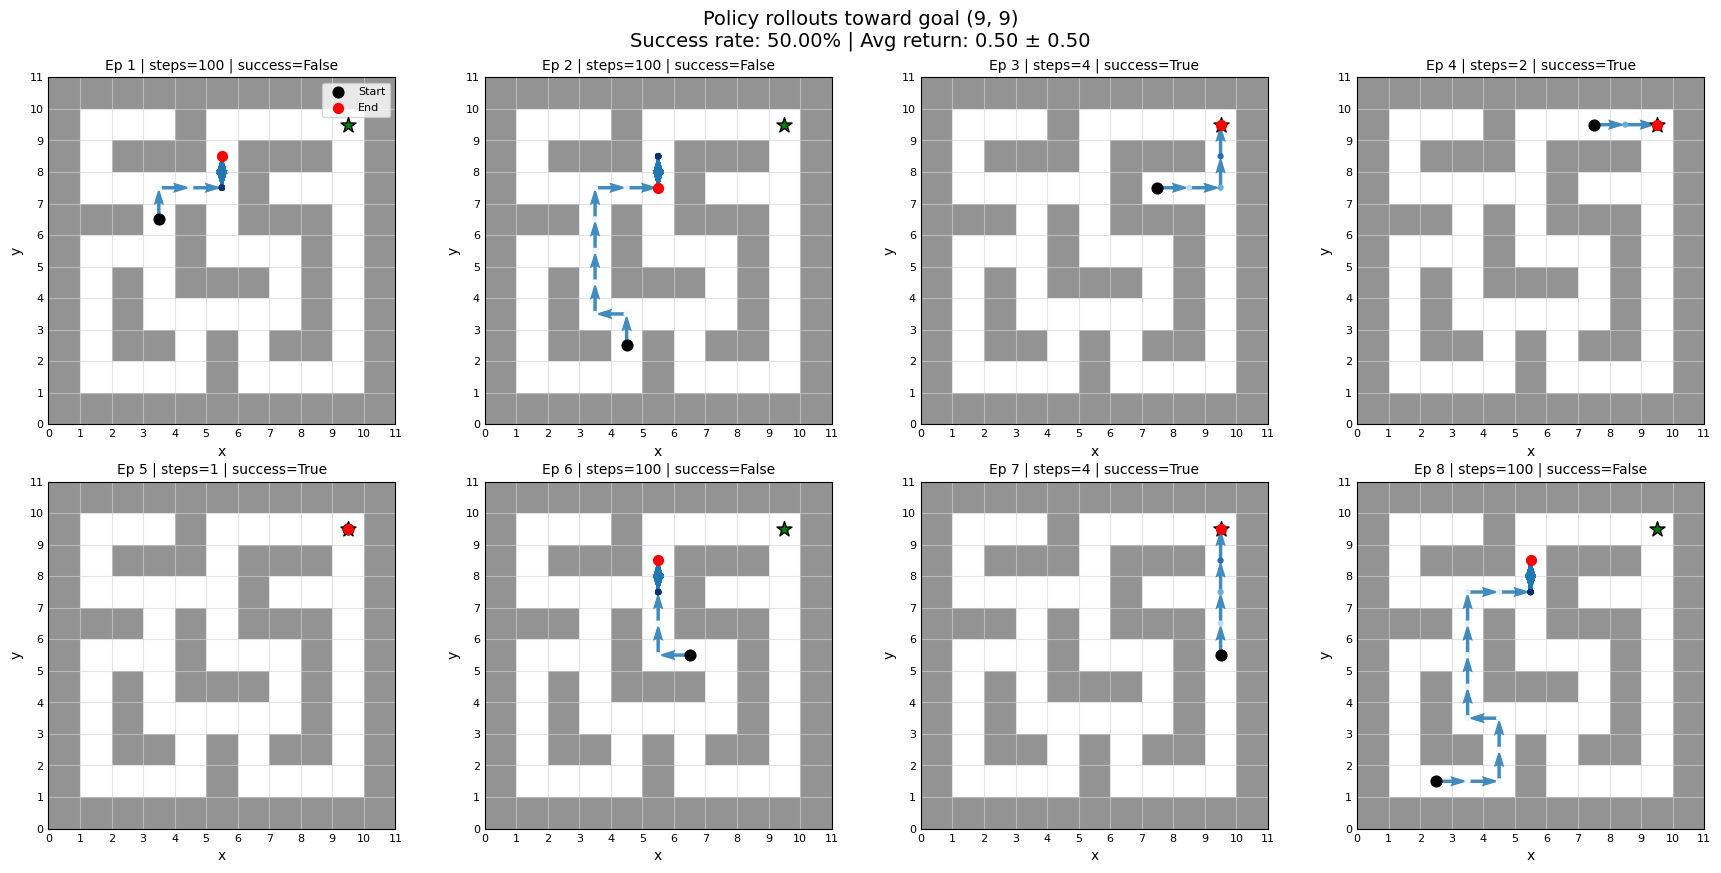

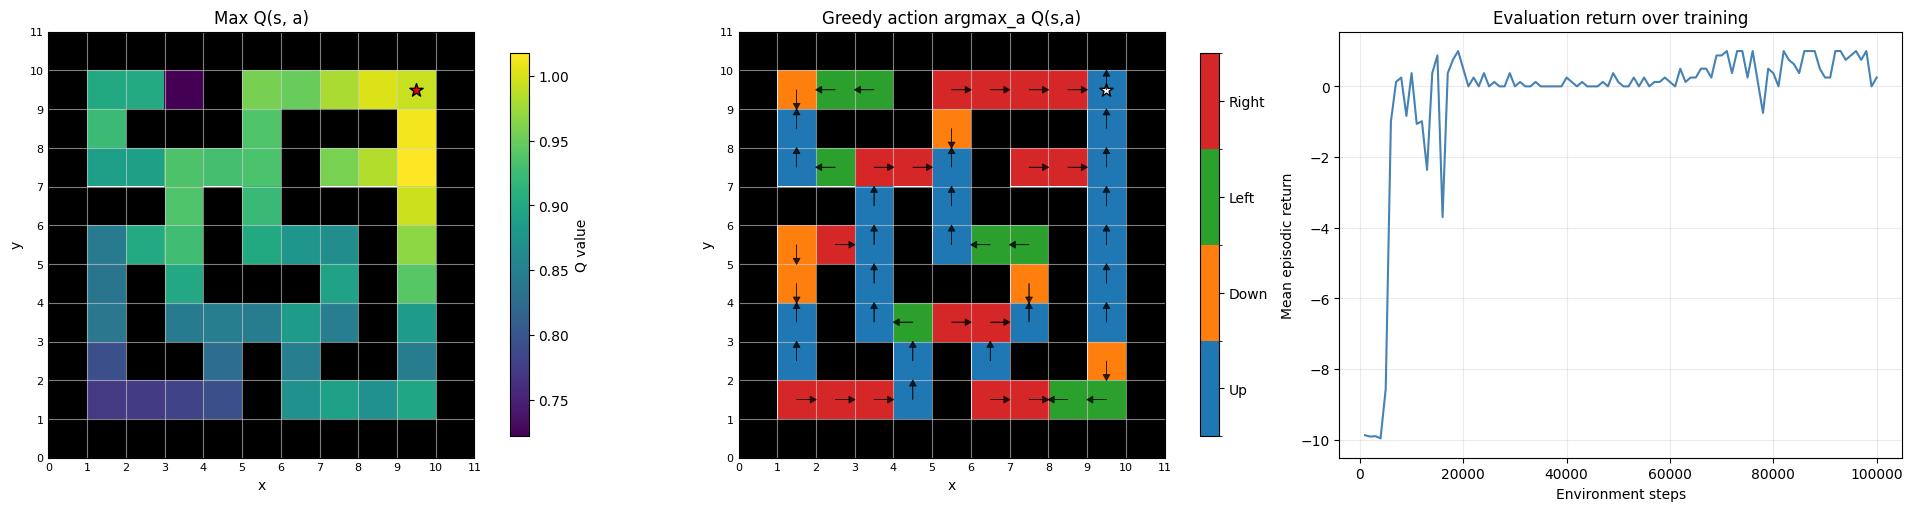

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.389513  4.180162  4.0064983 3.8132045 3.6521466]
cumulative variance (first 5 dims): [0.09350475 0.17830306 0.2562019  0.32676557 0.39149433]
cos(phi(s,a), psi/task): mean=0.0156, std=0.1164


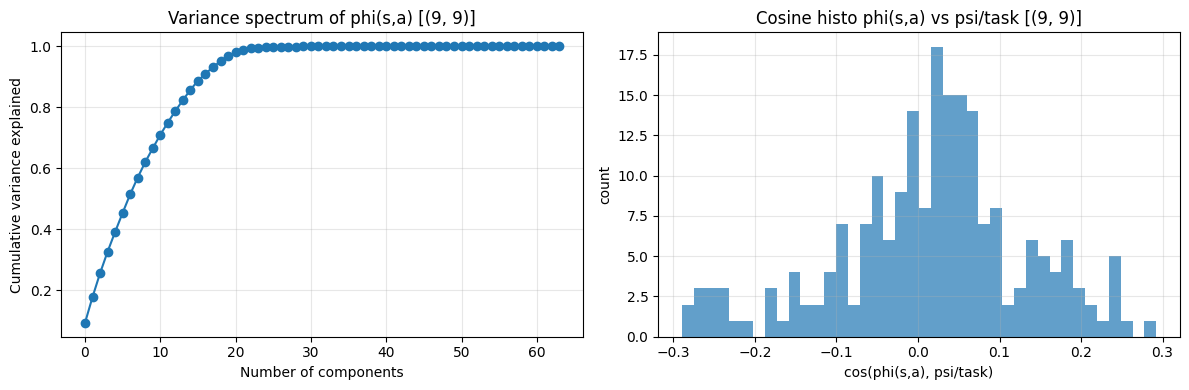


Goal embedding cosine similarity matrix:
     (9, 9)
  (9, 9)      1.000

----- seed=42, goal=(1, 1) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=0.000 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-2.400 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-2.450 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   4000 | eps=0.953 | eval_return=-1.212 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | 

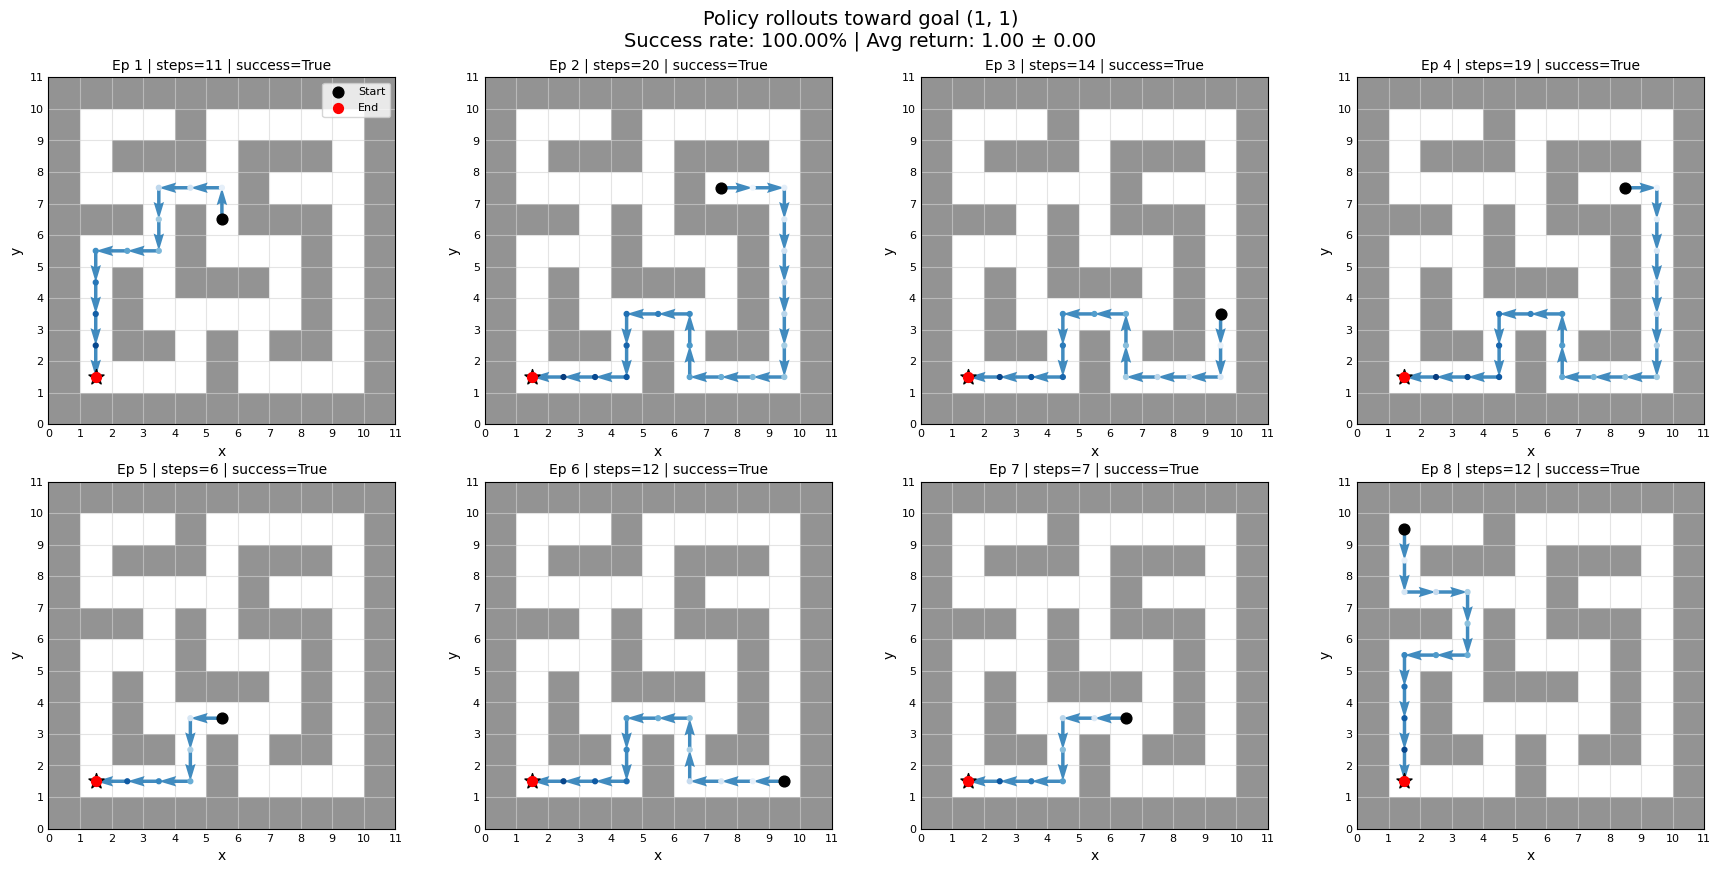

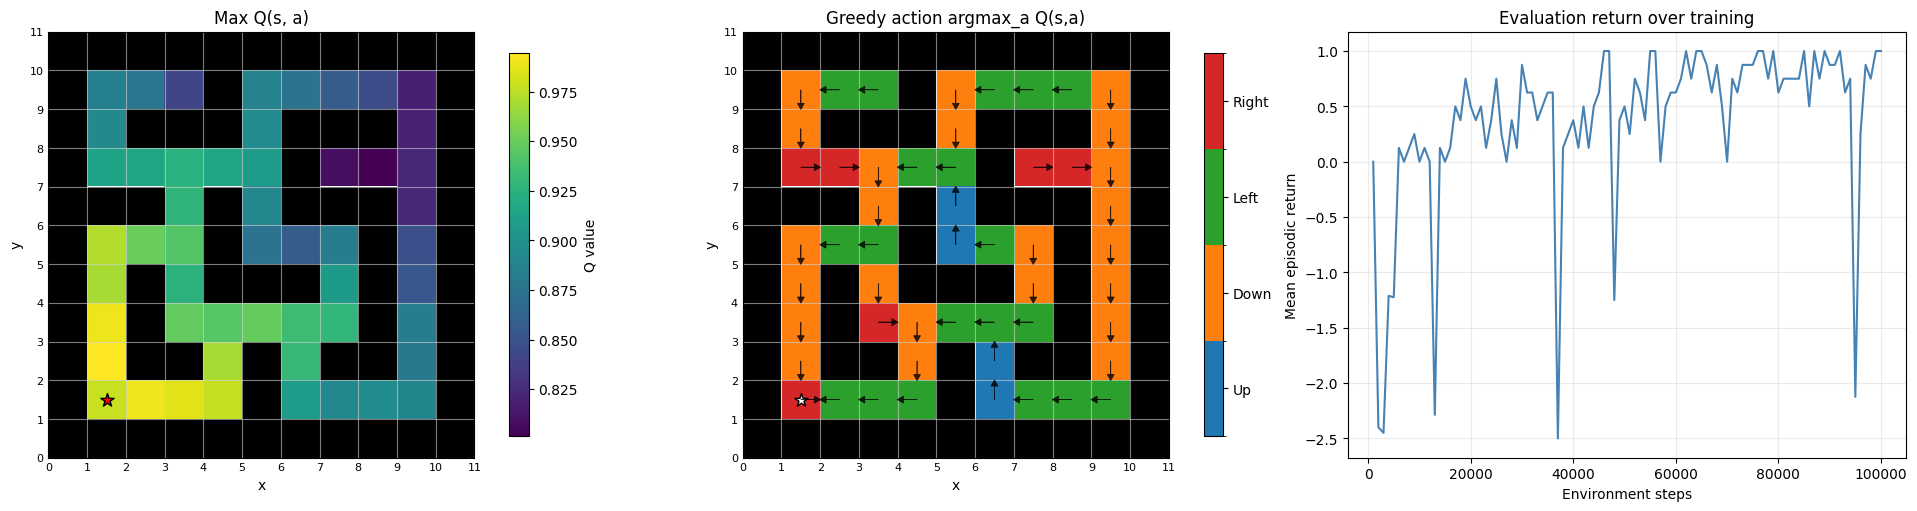

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [4.136867  3.9088085 3.840253  3.7231424 3.5578518]
cumulative variance (first 5 dims): [0.08261911 0.15638    0.22757626 0.29449636 0.35560647]
cos(phi(s,a), psi/task): mean=0.0119, std=0.1273


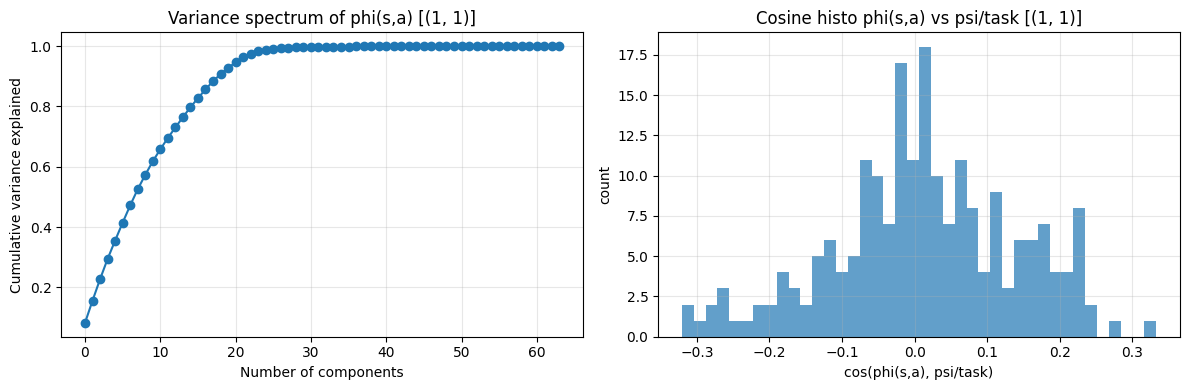


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)
  (9, 9)      1.000      0.993
  (1, 1)      0.993      1.000

Off-diagonal mean similarity: 0.993
Off-diagonal min similarity: 0.993
Off-diagonal max similarity: 0.993

----- seed=42, goal=(7, 7) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=0.000 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=0.000 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=0.000 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=

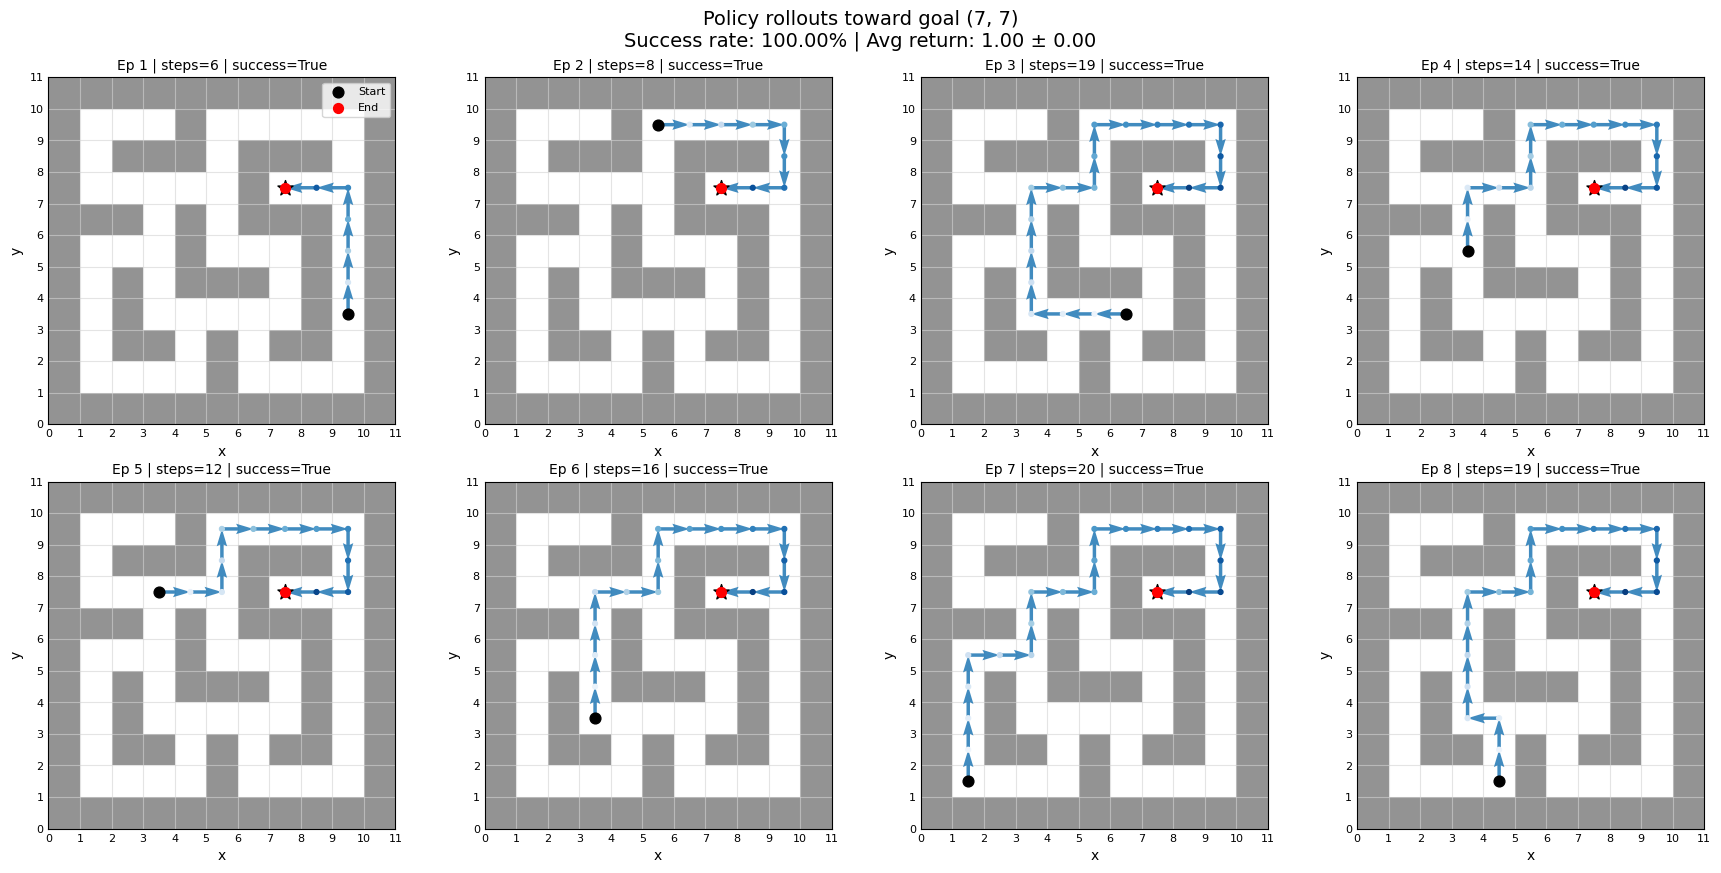

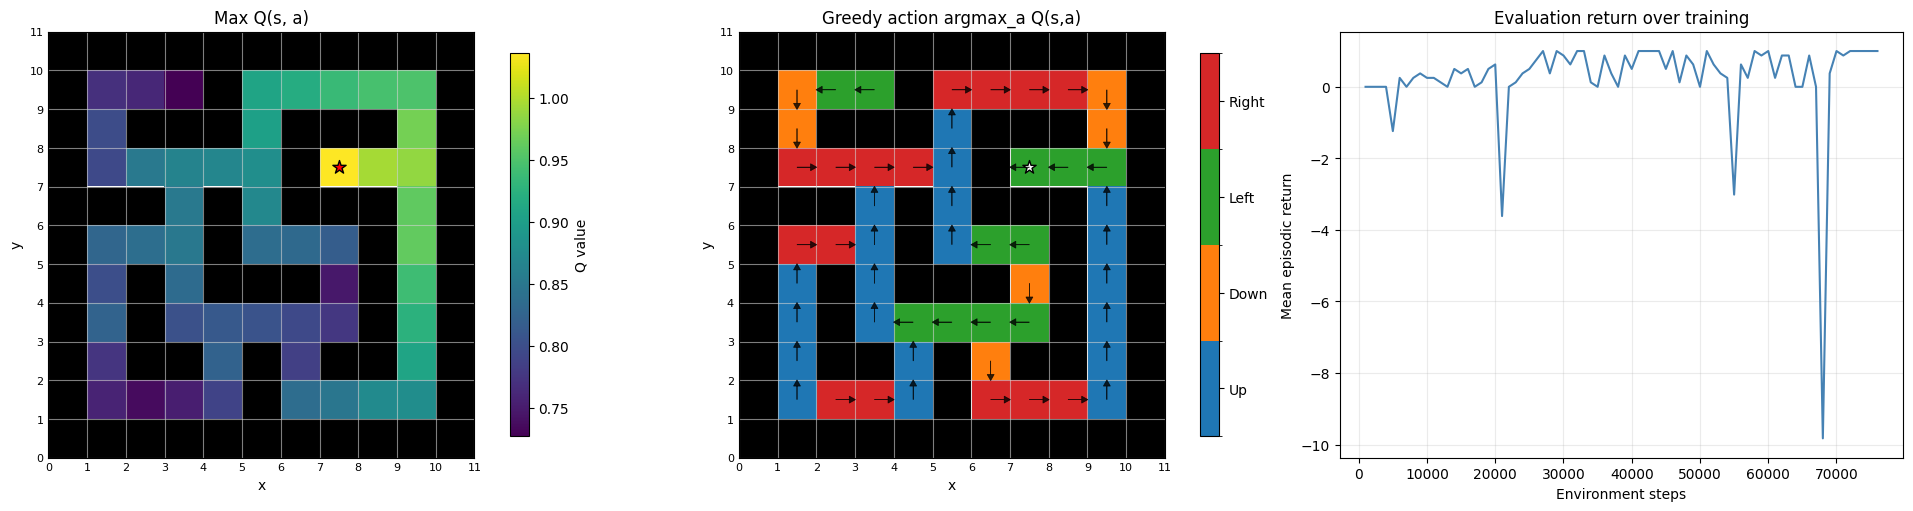

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6760163 3.4257    3.3717504 3.2483006 3.1634212]
cumulative variance (first 5 dims): [0.06550102 0.12238525 0.1774919  0.22863719 0.2771445 ]
cos(phi(s,a), psi/task): mean=0.0180, std=0.1369


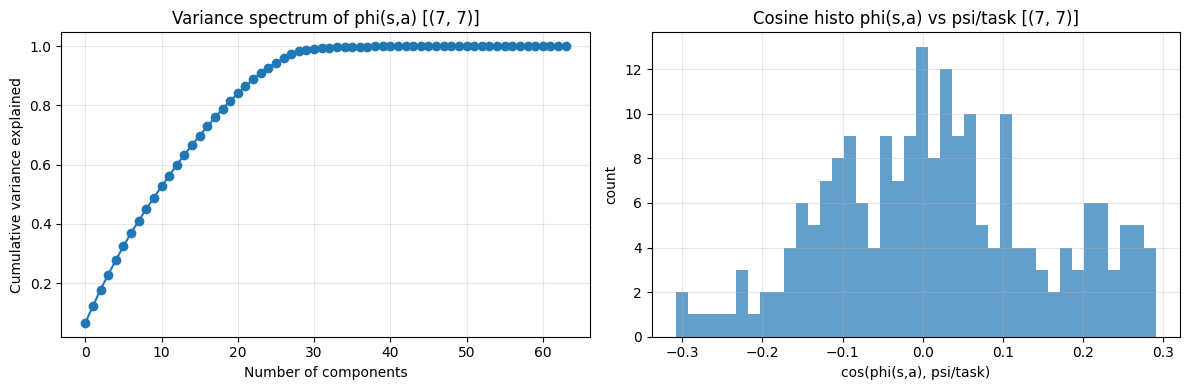


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)
  (9, 9)      1.000      0.993      0.989
  (1, 1)      0.993      1.000      0.996
  (7, 7)      0.989      0.996      1.000

Off-diagonal mean similarity: 0.993
Off-diagonal min similarity: 0.989
Off-diagonal max similarity: 0.996

----- seed=42, goal=(3, 5) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-4.225 | eval_len=51.8 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-6.537 | eval_len=76.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-7.875 | eval_len=88.2 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freez

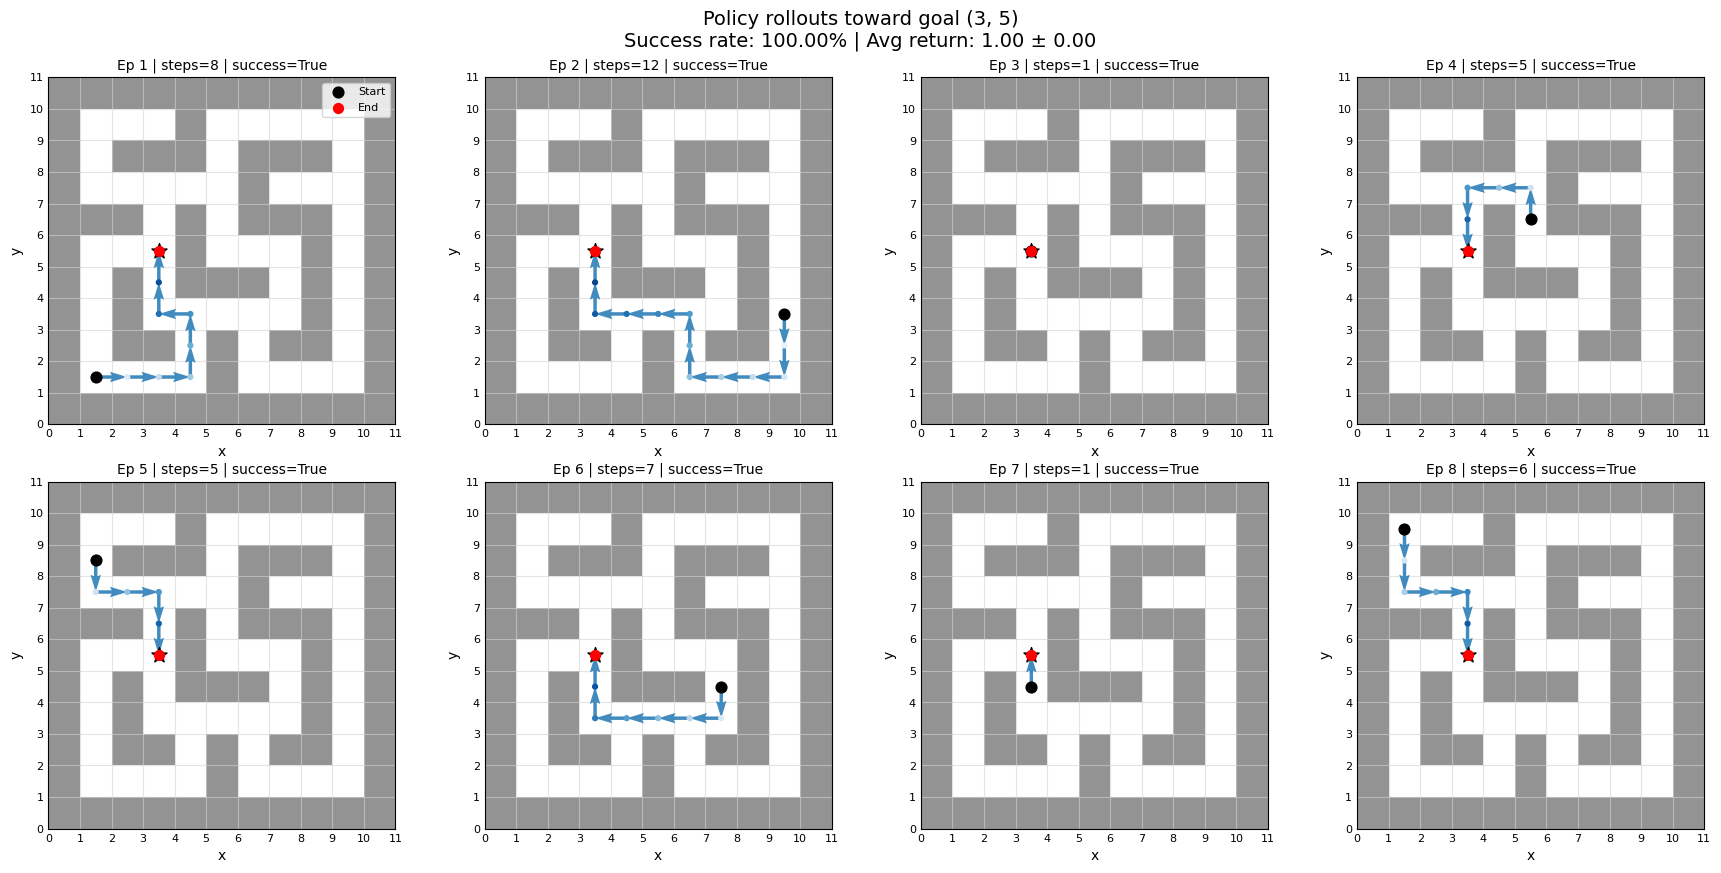

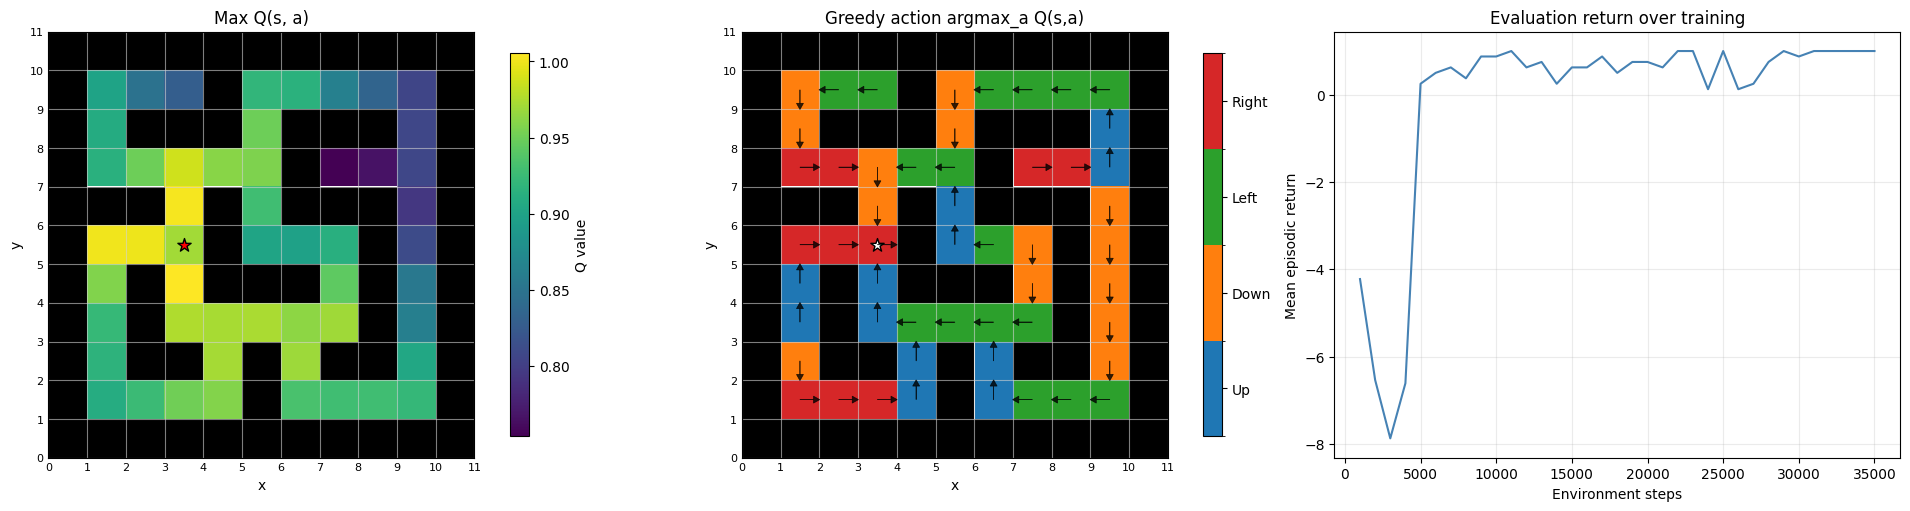

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.3360565 3.2433107 3.0807858 3.0407884 2.953461 ]
cumulative variance (first 5 dims): [0.05378268 0.10461651 0.15048334 0.19516693 0.23732087]
cos(phi(s,a), psi/task): mean=0.0160, std=0.1390


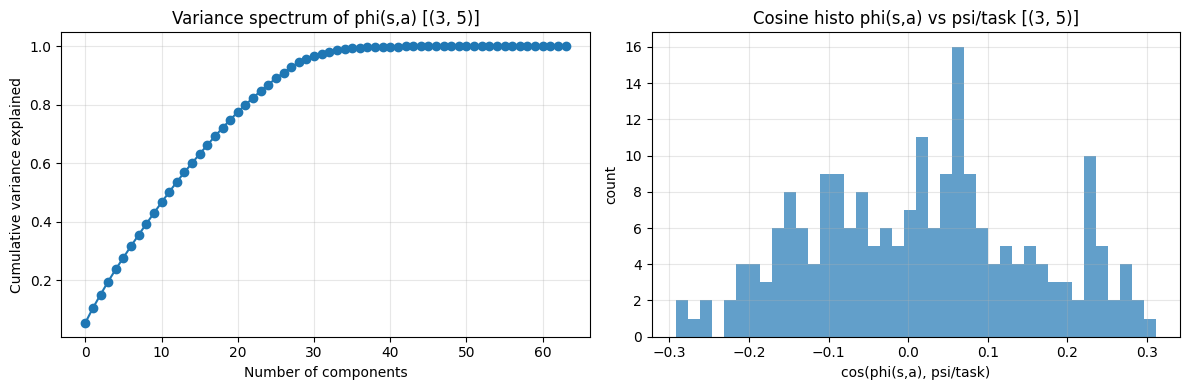


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)
  (9, 9)      1.000      0.993      0.989      0.984
  (1, 1)      0.993      1.000      0.996      0.994
  (7, 7)      0.989      0.996      1.000      0.999
  (3, 5)      0.984      0.994      0.999      1.000

Off-diagonal mean similarity: 0.993
Off-diagonal min similarity: 0.984
Off-diagonal max similarity: 0.999

----- seed=42, goal=(3, 9) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-9.212 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-9.400 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   3000 | eps=0.964 | eval_return=-9.487 | eval_len=100.0 | TD=

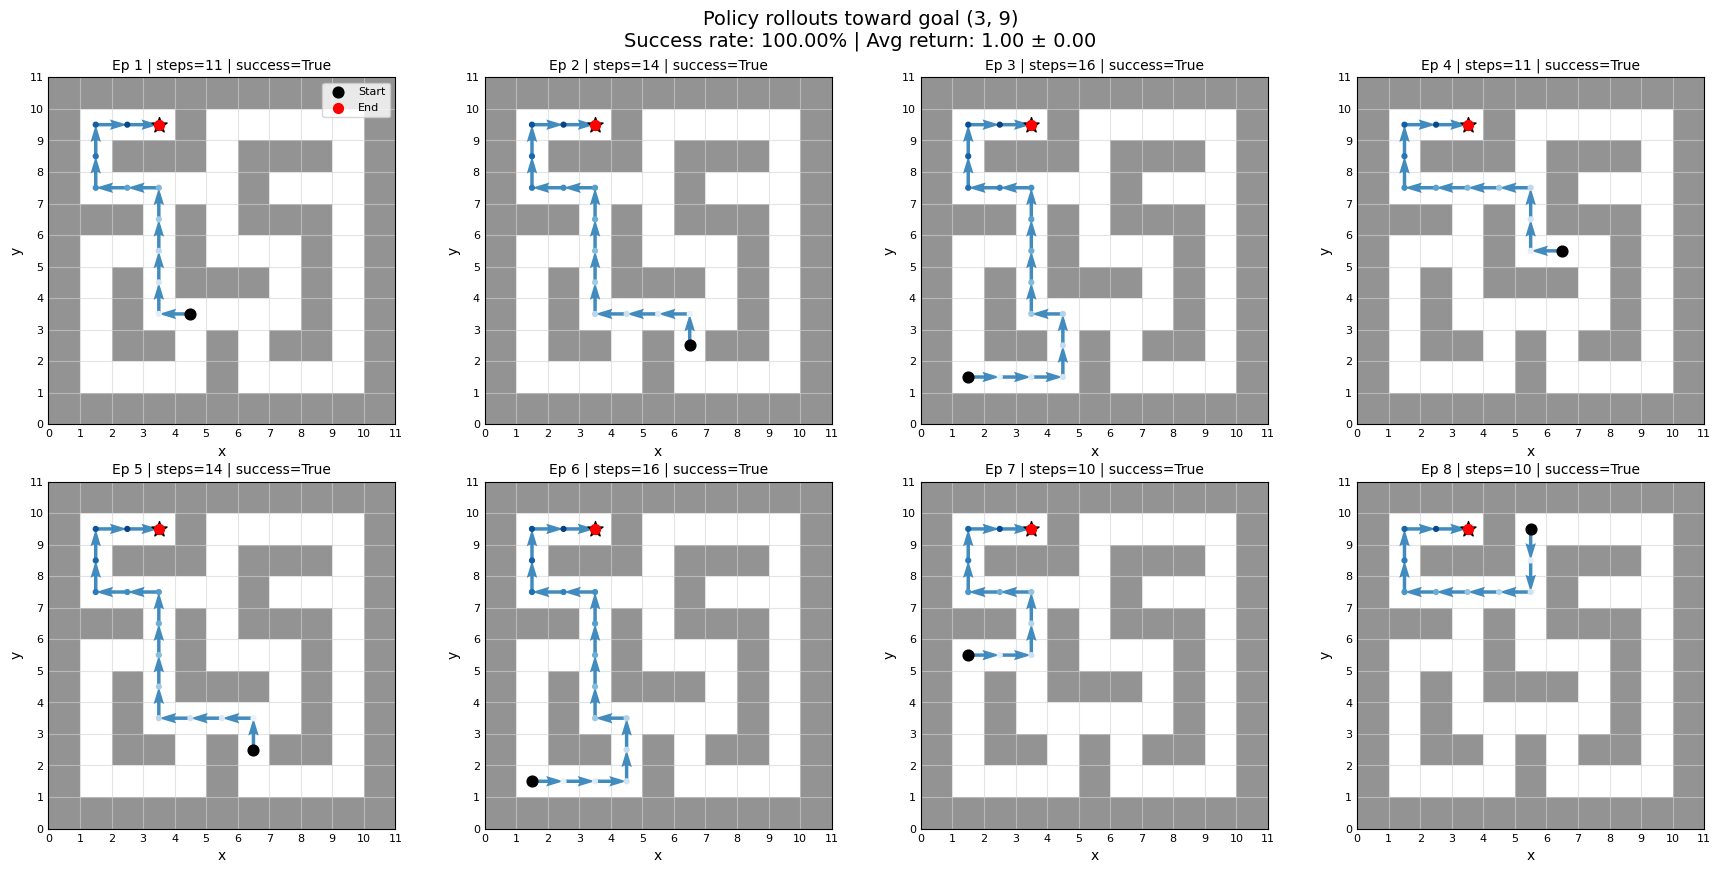

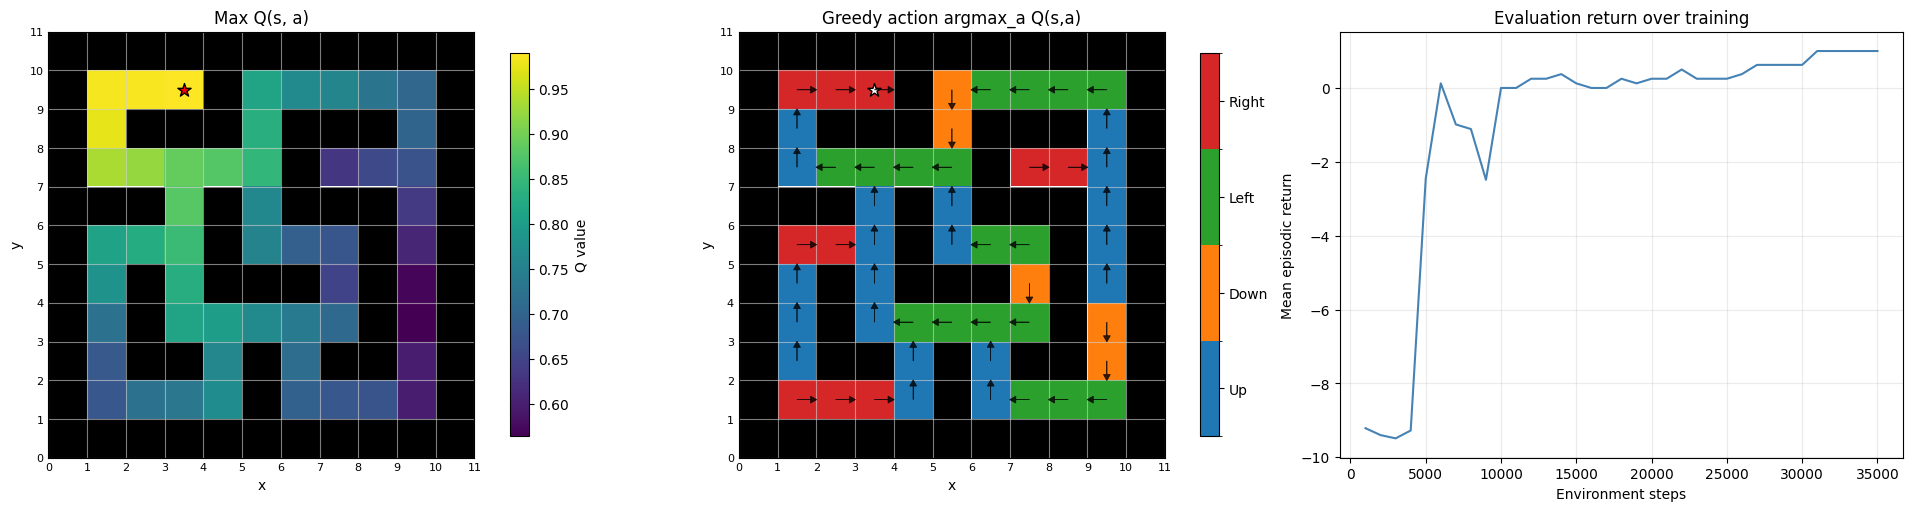

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.3454487 3.1451397 3.093721  3.034164  2.928724 ]
cumulative variance (first 5 dims): [0.05406018 0.10184045 0.1480712  0.19253913 0.23397015]
cos(phi(s,a), psi/task): mean=0.0161, std=0.1363


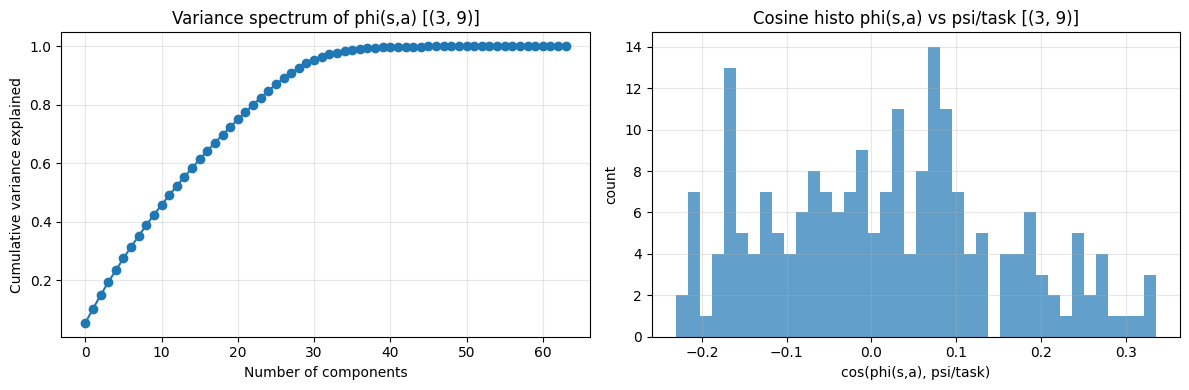


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)
  (9, 9)      1.000      0.993      0.989      0.984      0.977
  (1, 1)      0.993      1.000      0.996      0.994      0.989
  (7, 7)      0.989      0.996      1.000      0.999      0.995
  (3, 5)      0.984      0.994      0.999      1.000      0.998
  (3, 9)      0.977      0.989      0.995      0.998      1.000

Off-diagonal mean similarity: 0.991
Off-diagonal min similarity: 0.977
Off-diagonal max similarity: 0.999

----- seed=42, goal=(5, 5) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-8.925 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-7.337 | eval_len=87.8 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0

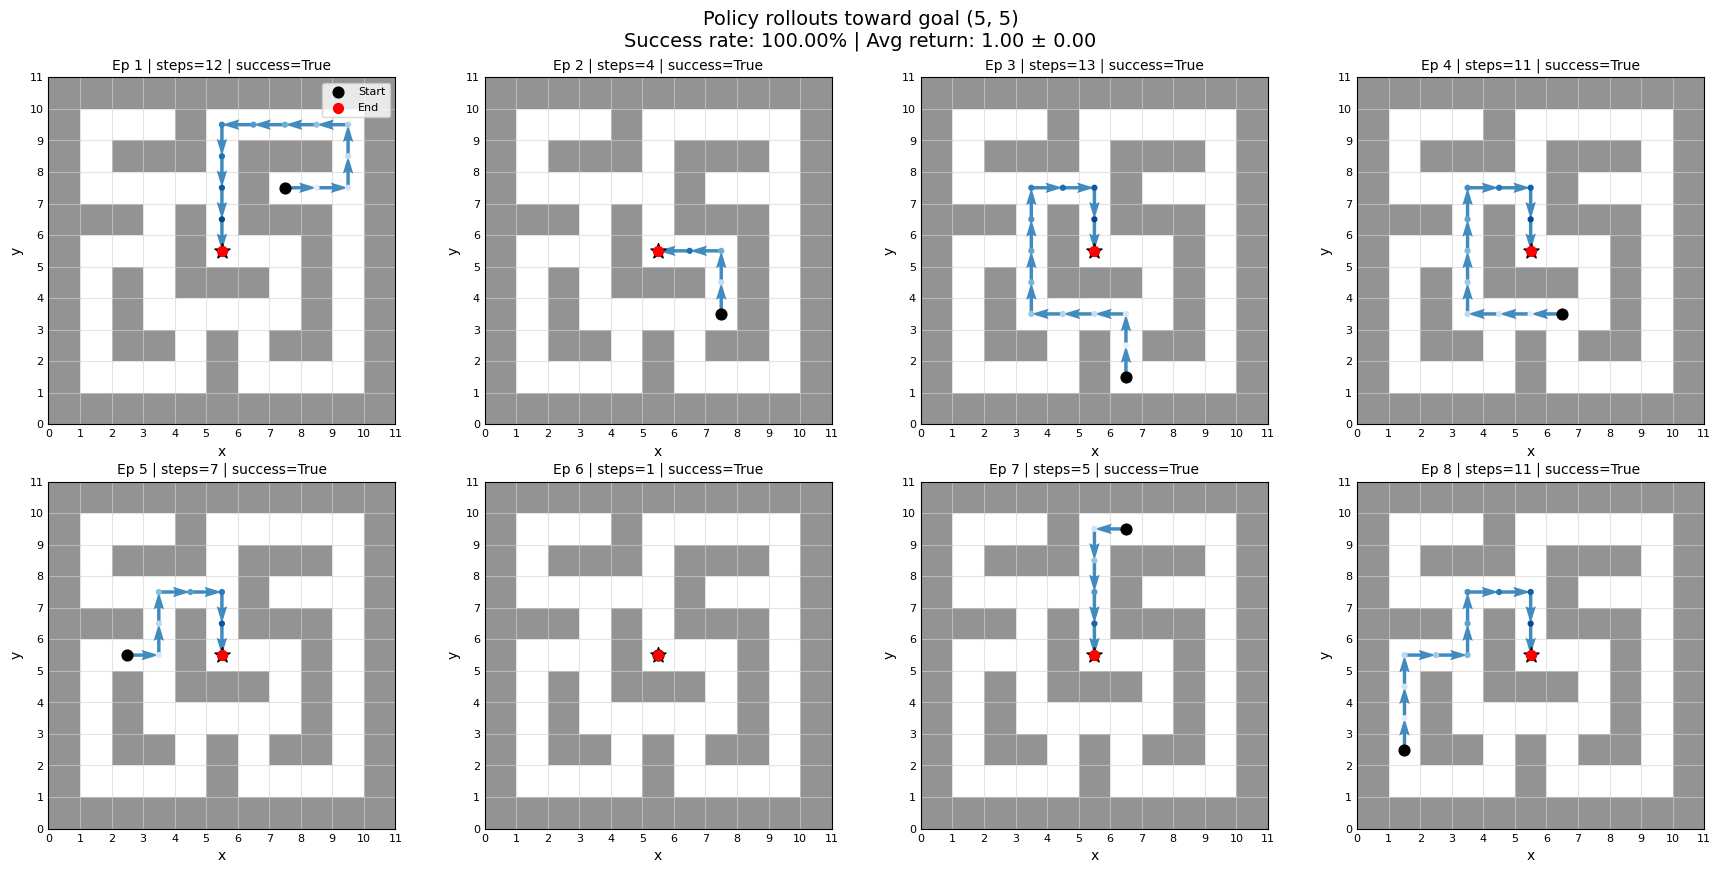

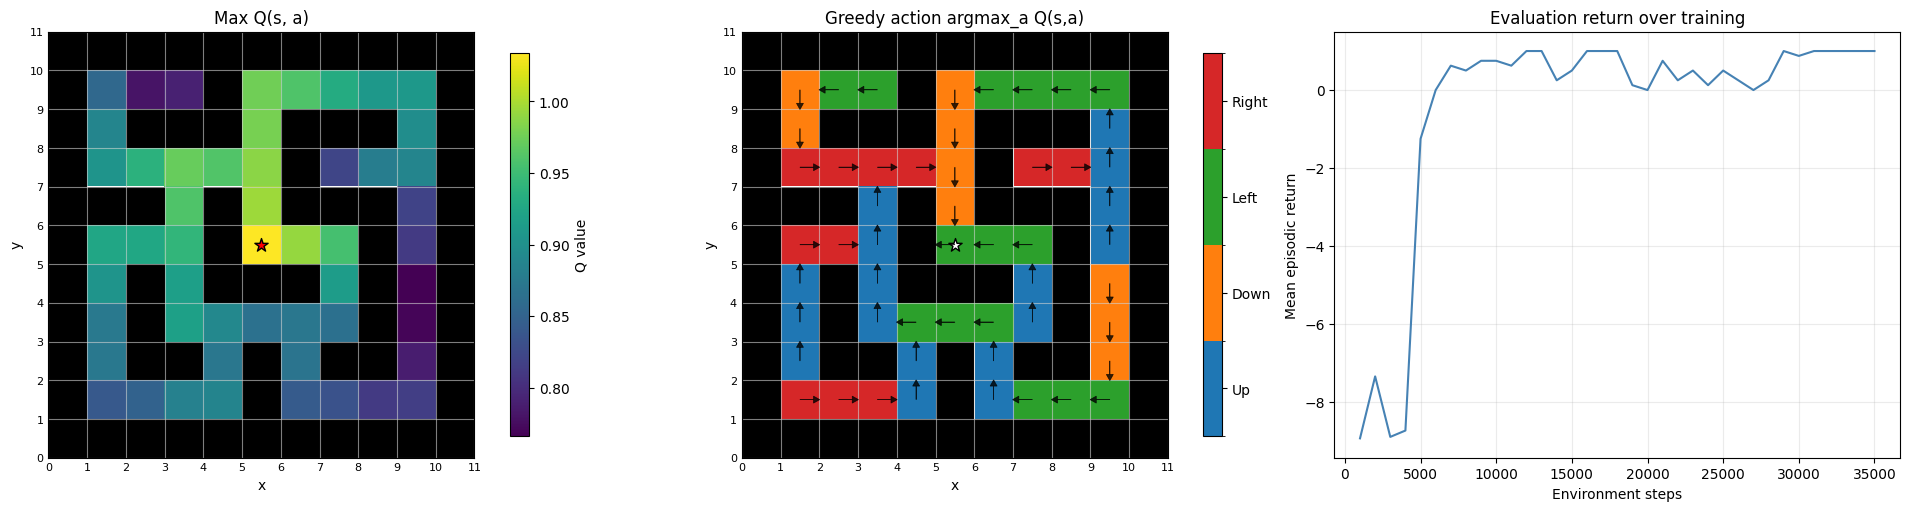

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.1889975 3.1021602 2.9861963 2.9019089 2.8680856]
cumulative variance (first 5 dims): [0.0492057  0.09576812 0.13891444 0.17965946 0.2194602 ]
cos(phi(s,a), psi/task): mean=0.0073, std=0.1294


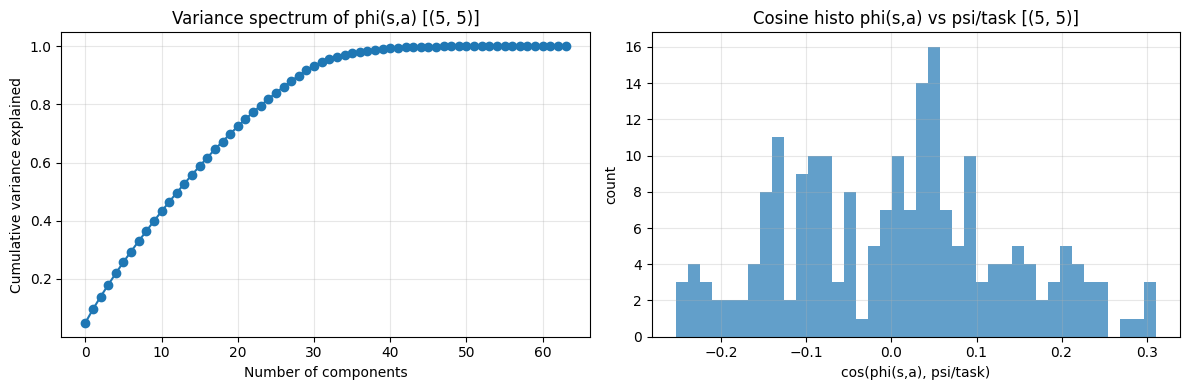


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000

Off-diagonal mean similarity: 0.992
Off-diagonal min similarity: 0.977
Off-diagonal max similarity: 0.999

----- seed=42, goal=(3, 6) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-1.587 | eval_len=30.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=0.0000 | offdiag=0.0000 | SigReg=0.0000 | freeze_sa=False| EWC_SA=0.0000000000 | EWC_NS=0.0000000000 
[DQN-MLP-head] step=   2000 | eps=0.976 | eval_return=-9.450 |

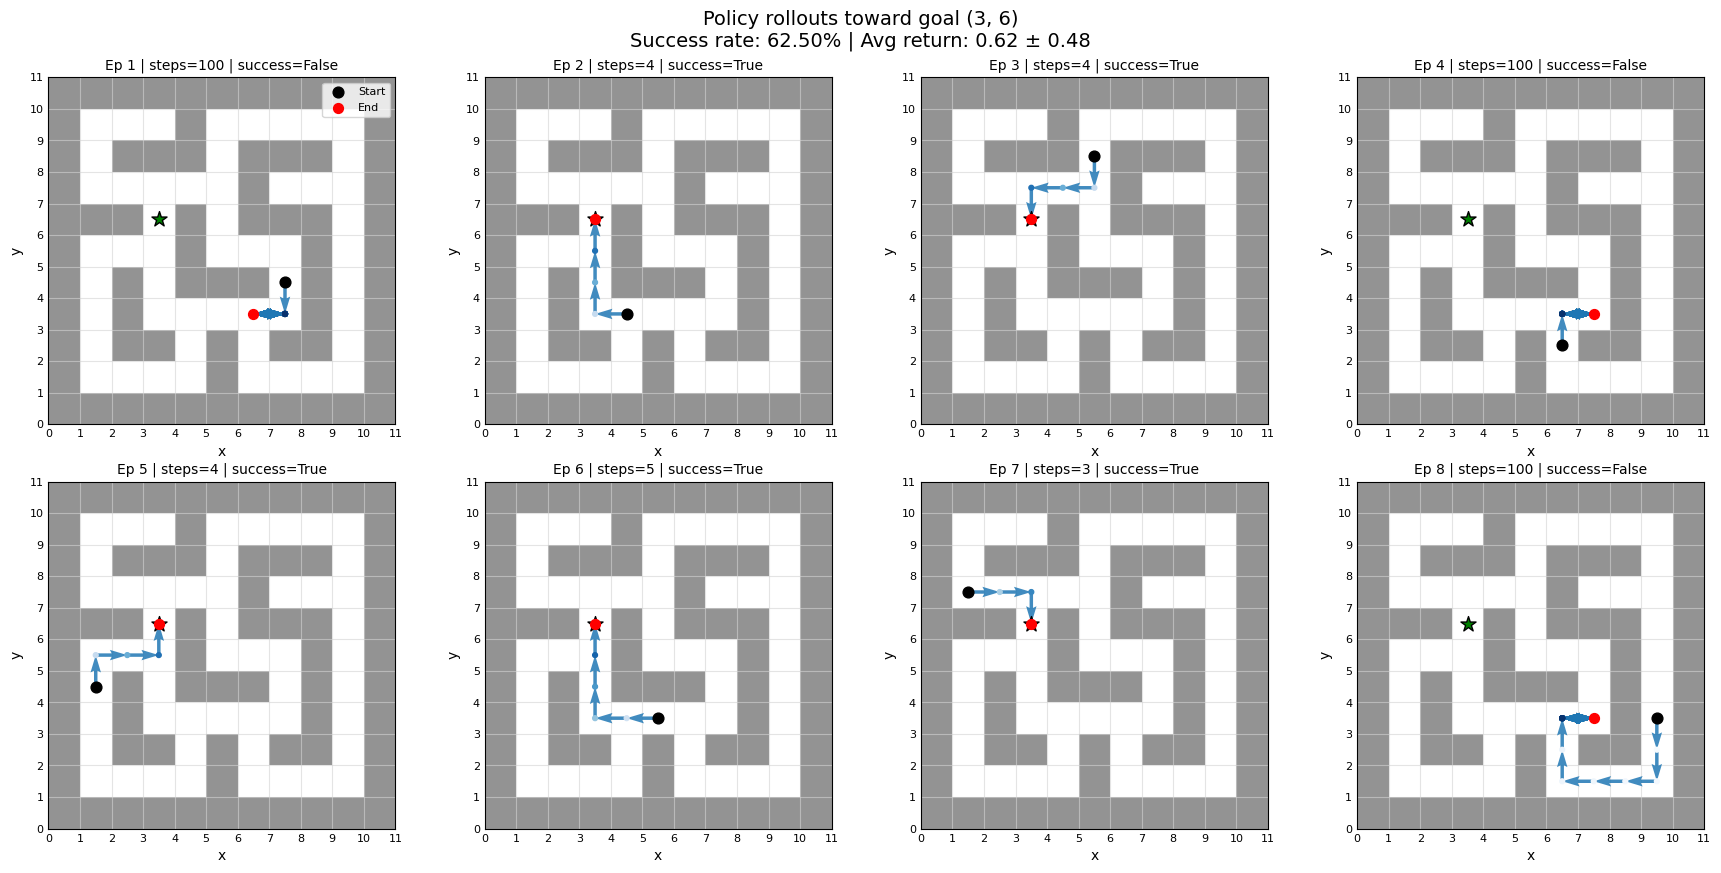

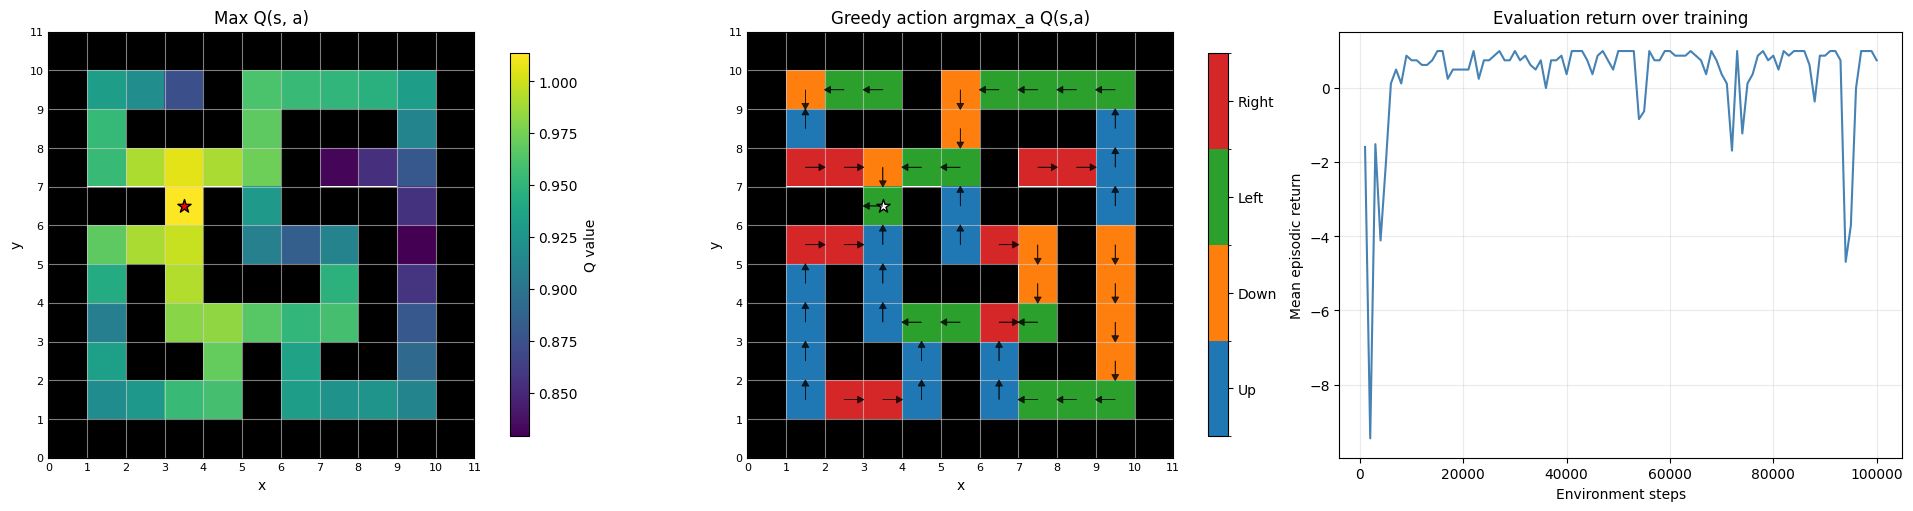

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.728746  3.3683538 3.0833607 3.0302732 2.9655945]
cumulative variance (first 5 dims): [0.06740656 0.12241282 0.16850479 0.21302325 0.25566158]
cos(phi(s,a), psi/task): mean=0.0221, std=0.1221


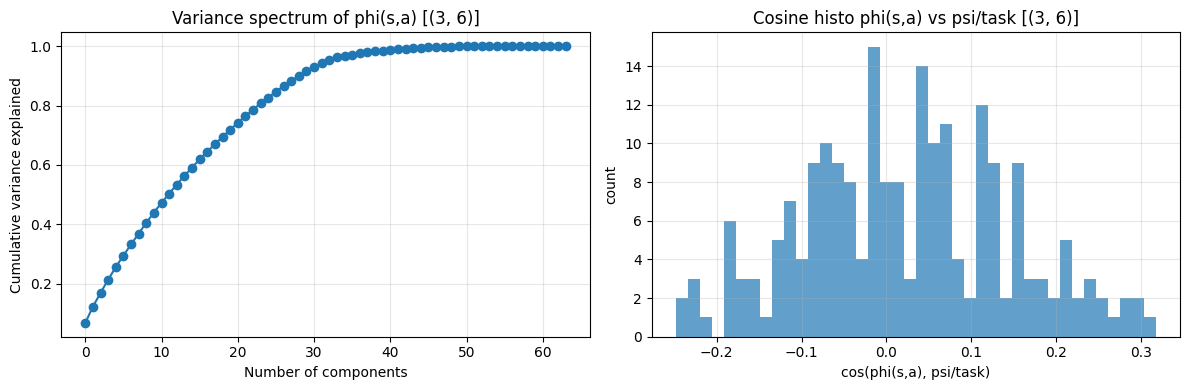


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978      0.971
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989      0.981
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997      0.993
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998      0.994
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999      0.995
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000      0.997
  (3, 6)      0.971      0.981      0.993      0.994      0.995      0.997      1.000

Off-diagonal mean similarity: 0.991
Off-diagonal min similarity: 0.971
Off-diagonal max similarity: 0.999

----- seed=42, goal=(9, 1) -----

[DQN-MLP-head] step=   1000 | eps=0.988 | eval_return=-2.437 | eval_len=100.0 | TD=0.0000 | Contrastive=0.0000 | DynTotal=0.0000 | diag=

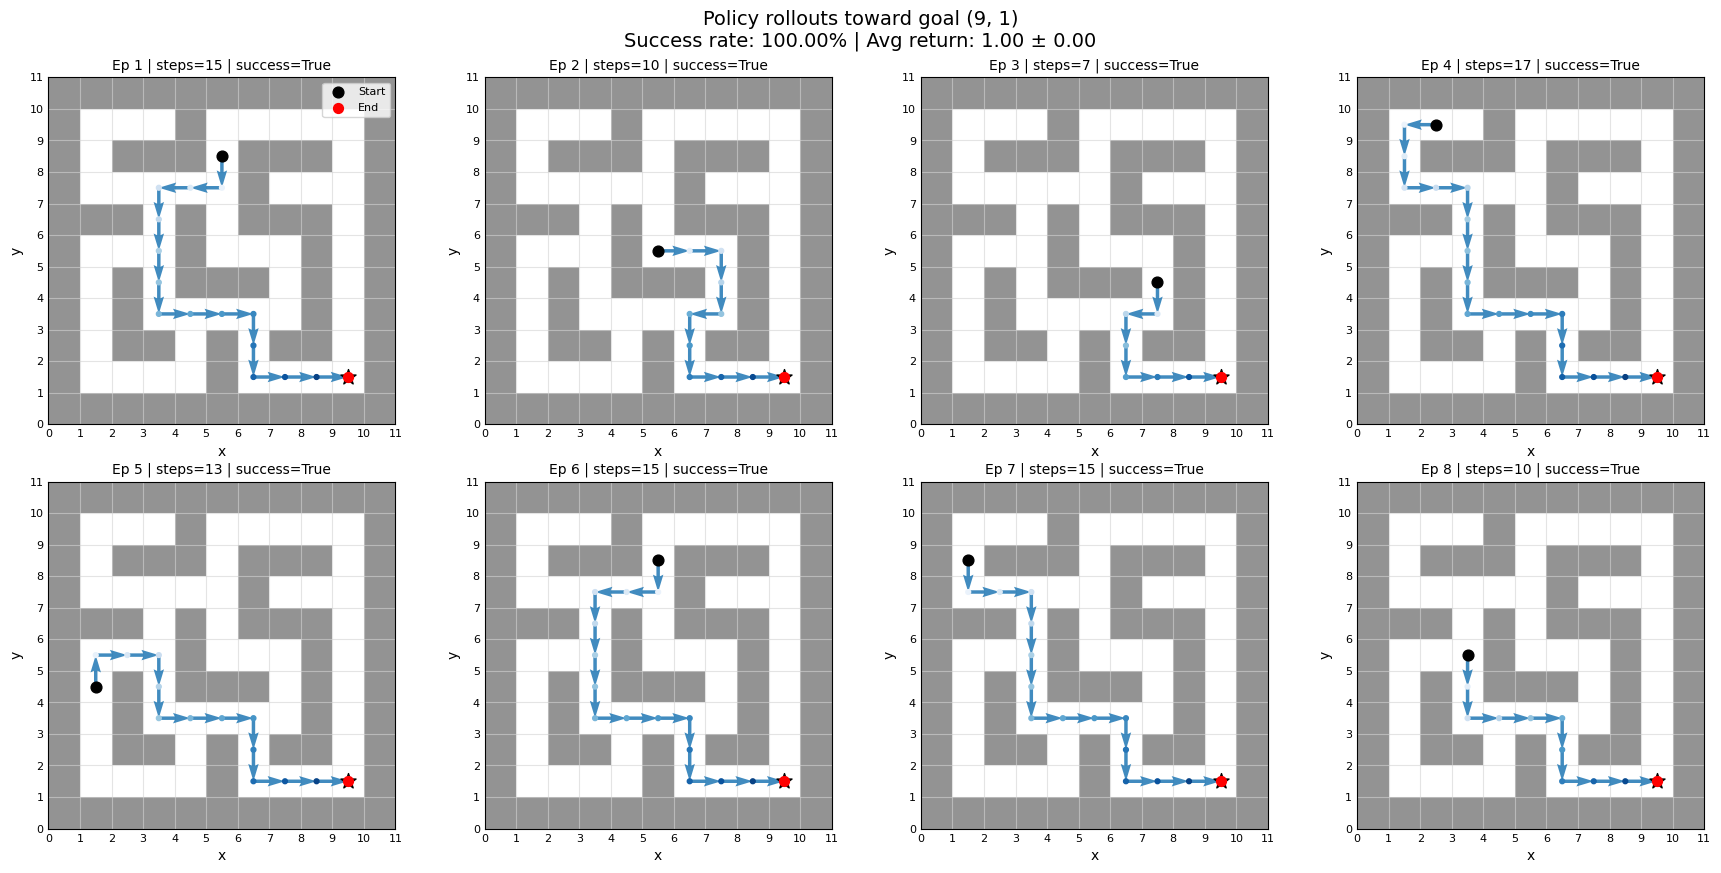

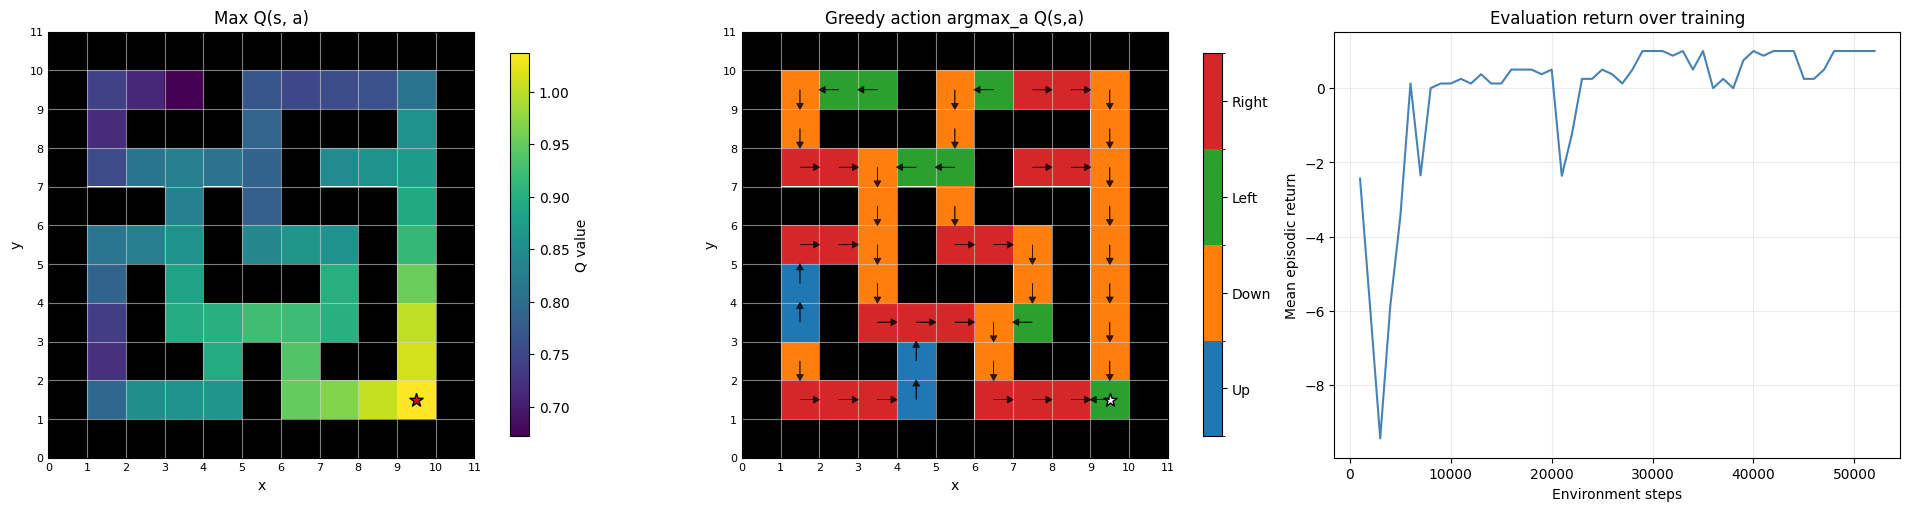

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4084964 3.379847  3.2109578 3.06859   3.010397 ]
cumulative variance (first 5 dims): [0.05623848 0.11153553 0.16144432 0.2070255  0.25089425]
cos(phi(s,a), psi/task): mean=0.0089, std=0.1266


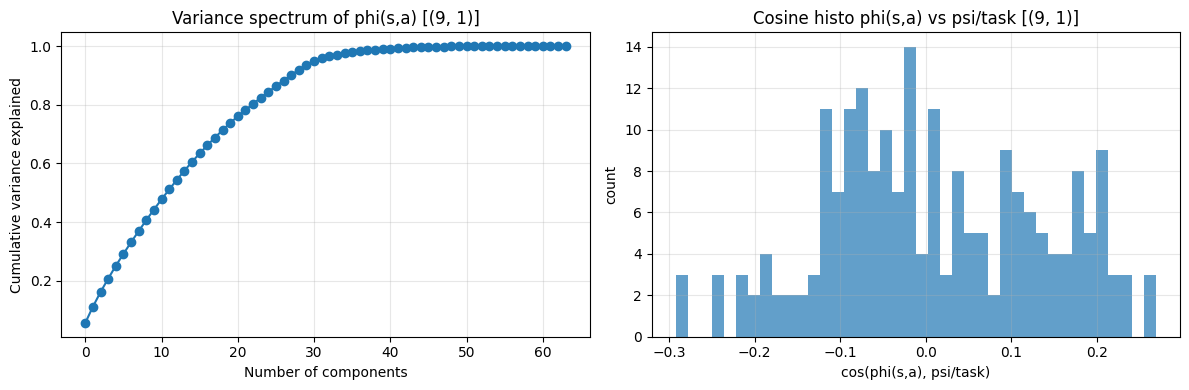


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978      0.971      0.965
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989      0.981      0.977
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997      0.993      0.991
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998      0.994      0.992
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999      0.995      0.992
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000      0.997      0.994
  (3, 6)      0.971      0.981      0.993      0.994      0.995      0.997      1.000      0.998
  (9, 1)      0.965      0.977      0.991      0.992      0.992      0.994      0.998      1.000

Off-diagonal mean similarity: 0.990
Off-diagonal min similarity: 0.965
Off-diagonal max simi

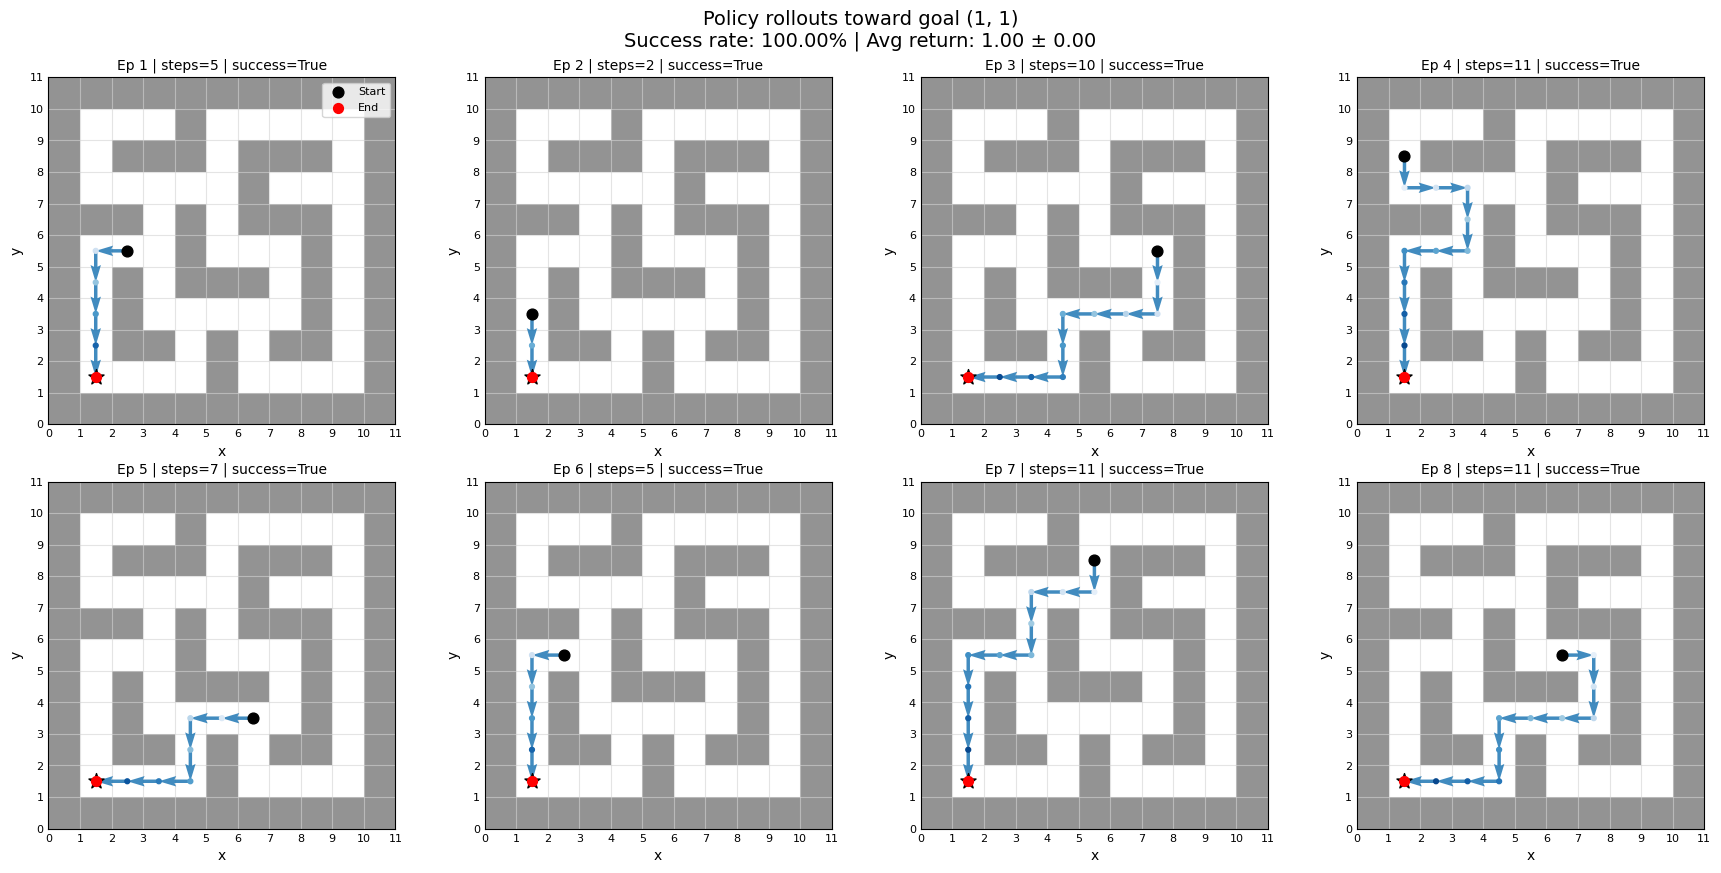

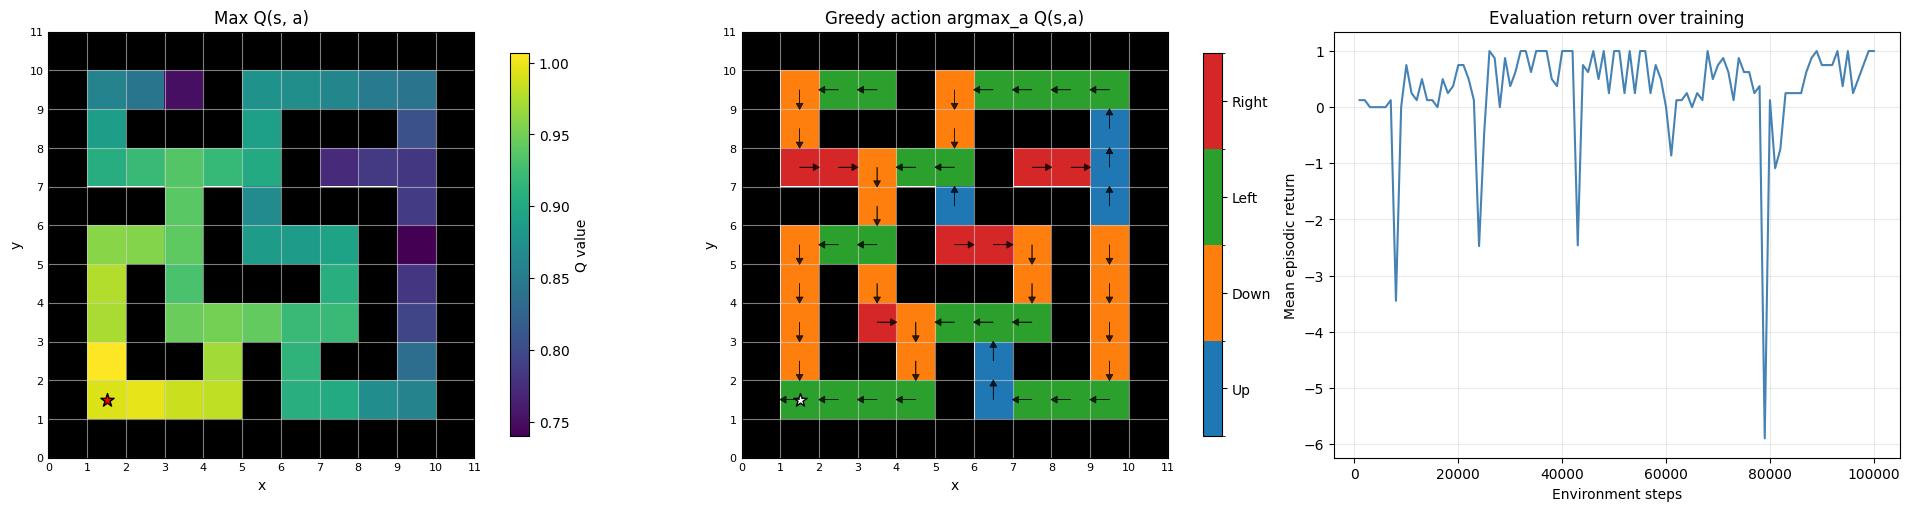

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6544938 3.343868  3.14872   3.008376  2.9125843]
cumulative variance (first 5 dims): [0.06466908 0.11881185 0.16681948 0.21064292 0.25171995]
cos(phi(s,a), psi/task): mean=0.0013, std=0.1290


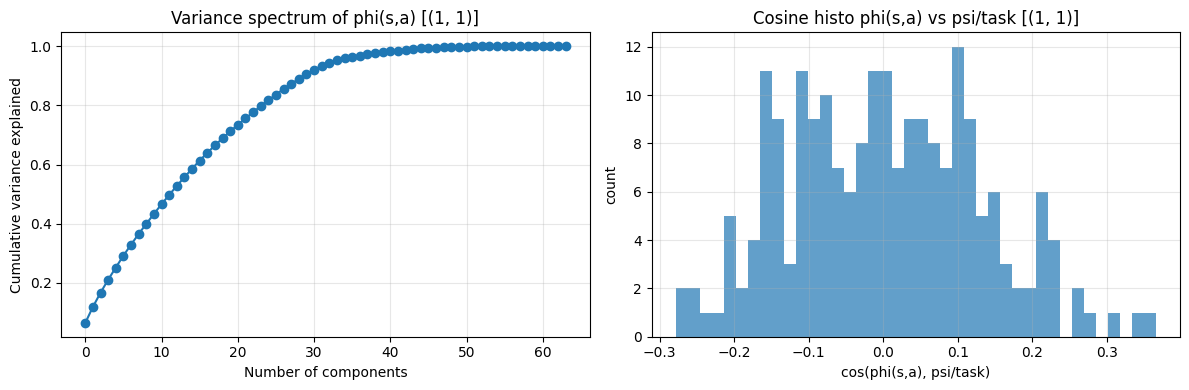


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978      0.971      0.965      0.965
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989      0.981      0.977      0.978
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997      0.993      0.991      0.991
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998      0.994      0.992      0.994
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999      0.995      0.992      0.992
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000      0.997      0.994      0.993
  (3, 6)      0.971      0.981      0.993      0.994      0.995      0.997      1.000      0.998      0.995
  (9, 1)      0.965      0.977      0.991      0.992      0.992      0.994      0.998      1.000      

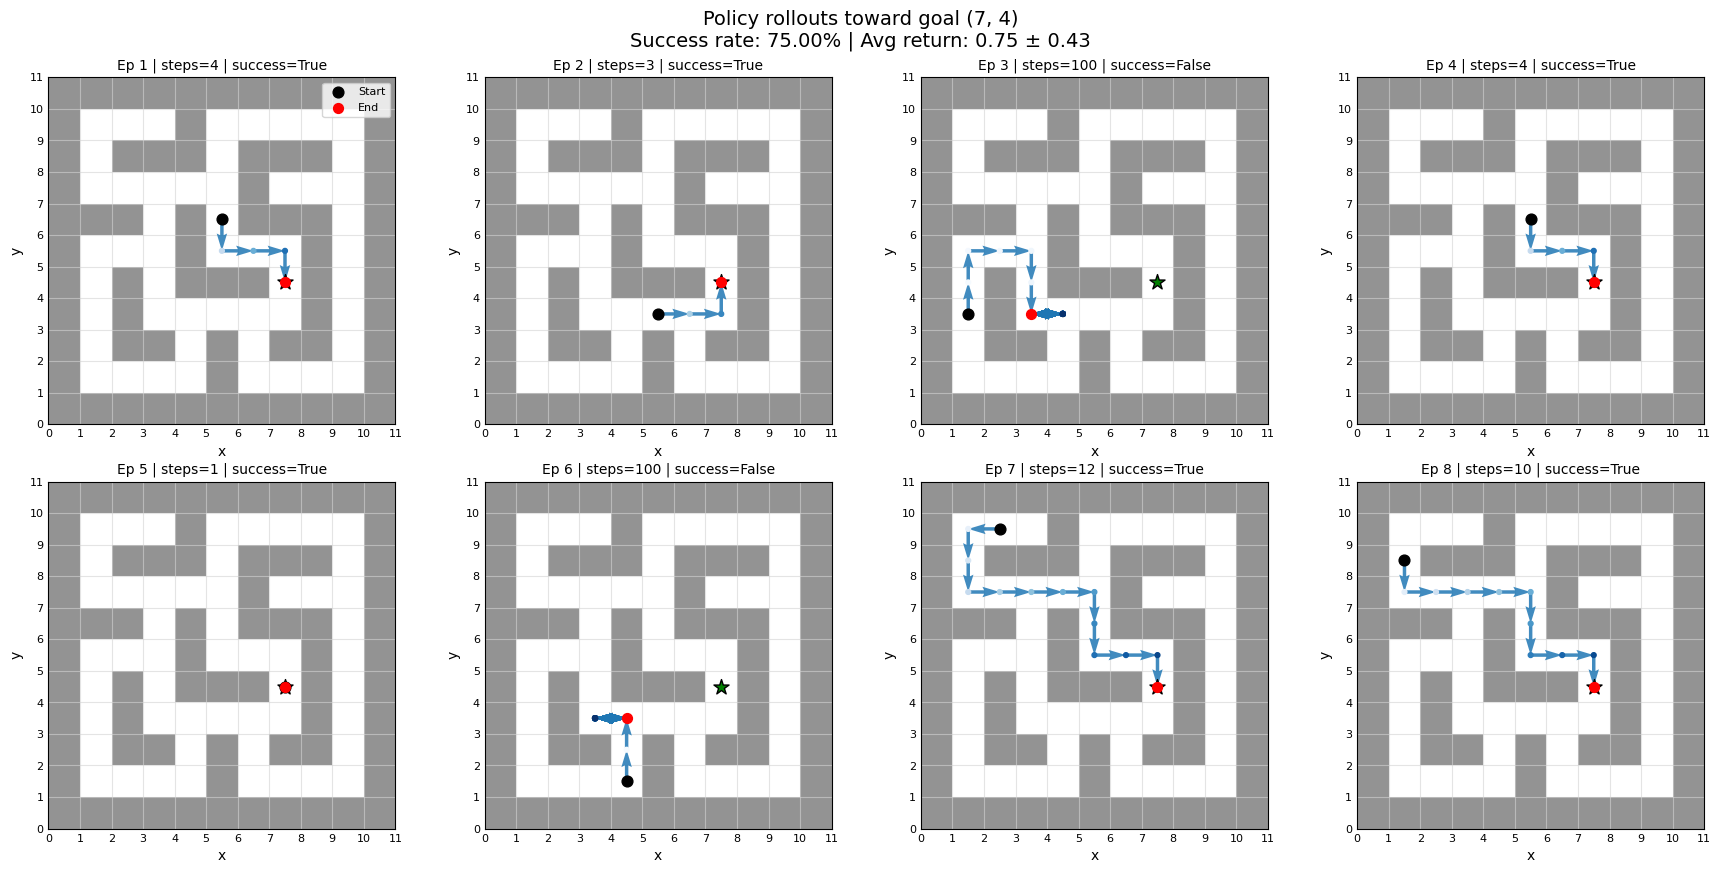

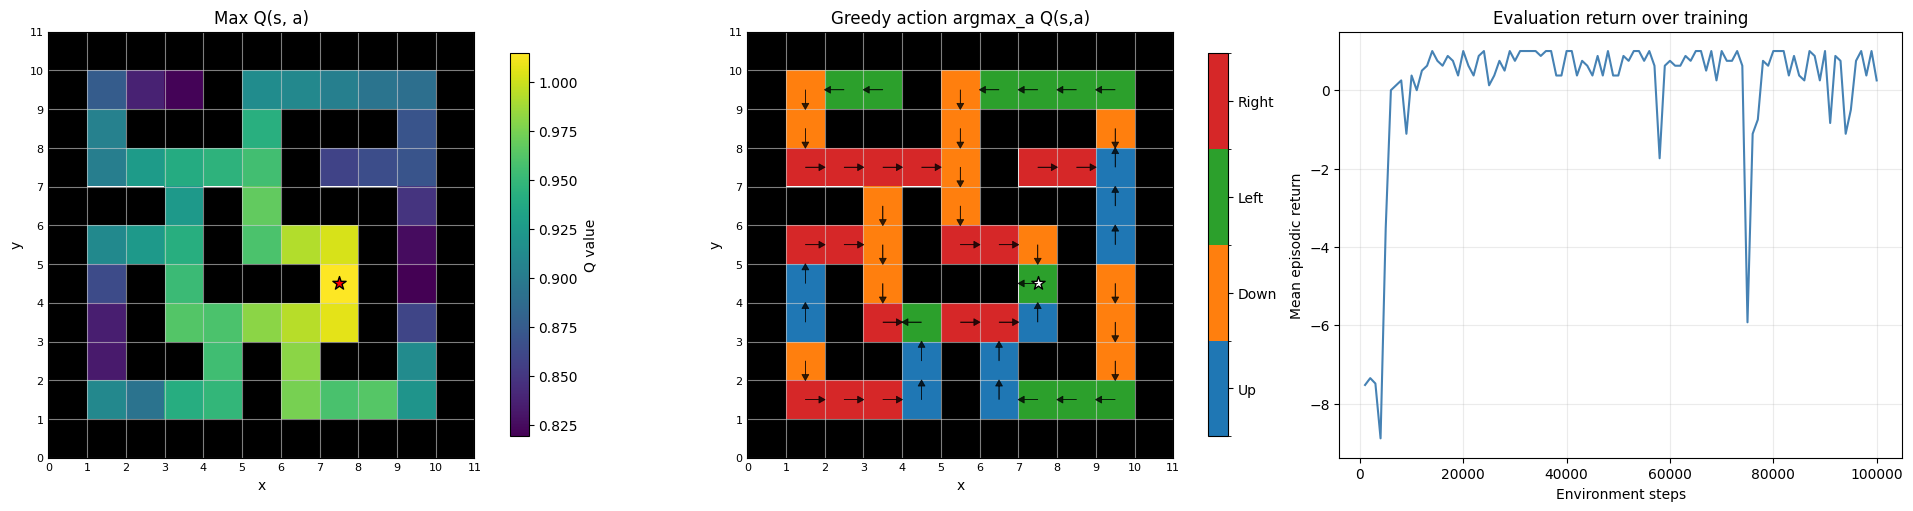

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.0857413 2.960488  2.8270335 2.7892282 2.7538795]
cumulative variance (first 5 dims): [0.04616609 0.08866039 0.12740988 0.16512991 0.20189995]
cos(phi(s,a), psi/task): mean=0.0147, std=0.1199


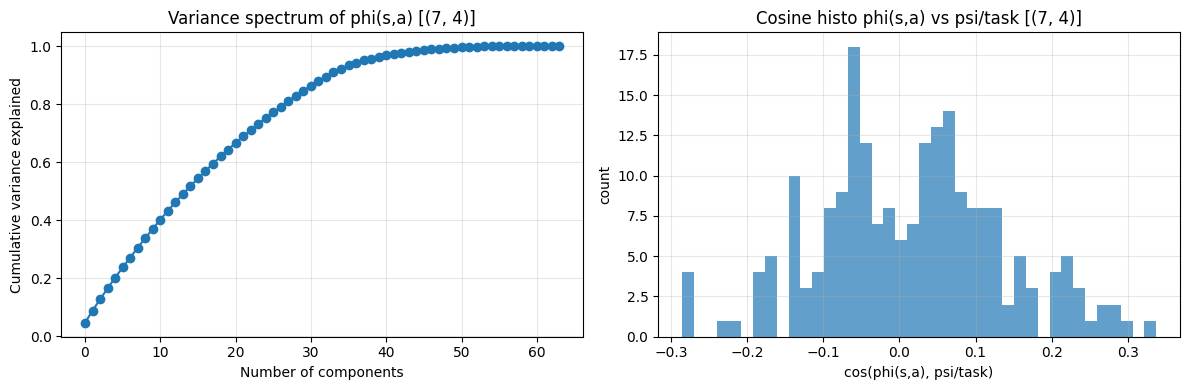


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978      0.971      0.965      0.965      0.950
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989      0.981      0.977      0.978      0.963
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997      0.993      0.991      0.991      0.979
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998      0.994      0.992      0.994      0.983
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999      0.995      0.992      0.992      0.980
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000      0.997      0.994      0.993      0.980
  (3, 6)      0.971      0.981      0.993      0.994      0.995      0.997      1.000      0.998      0.995      0.982
  (9, 1)      

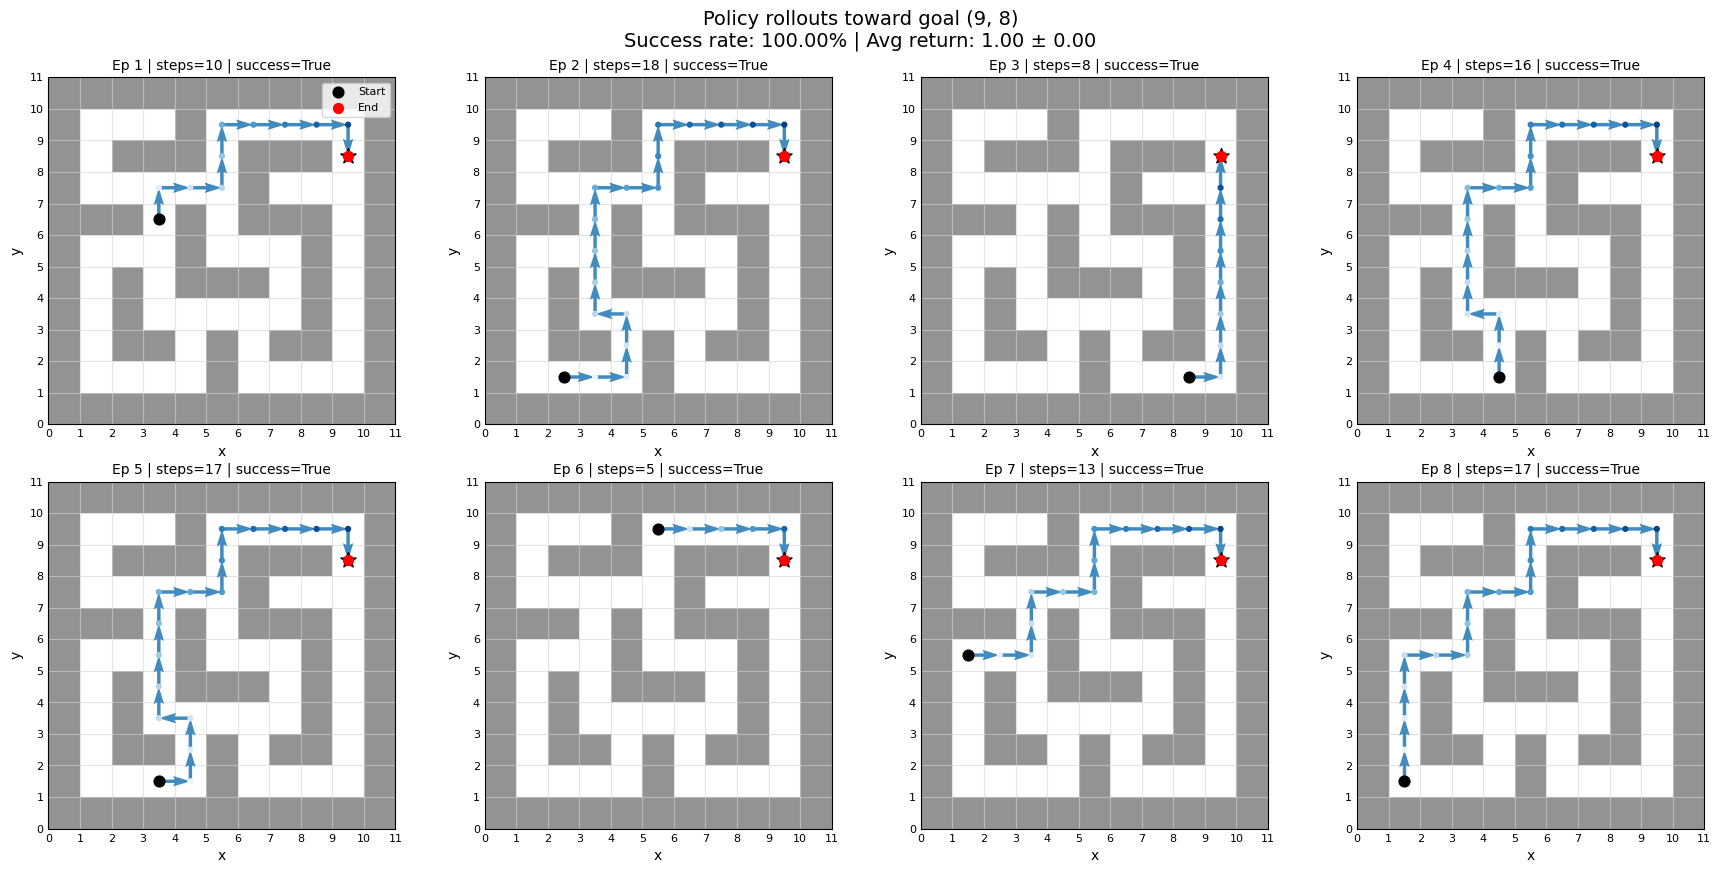

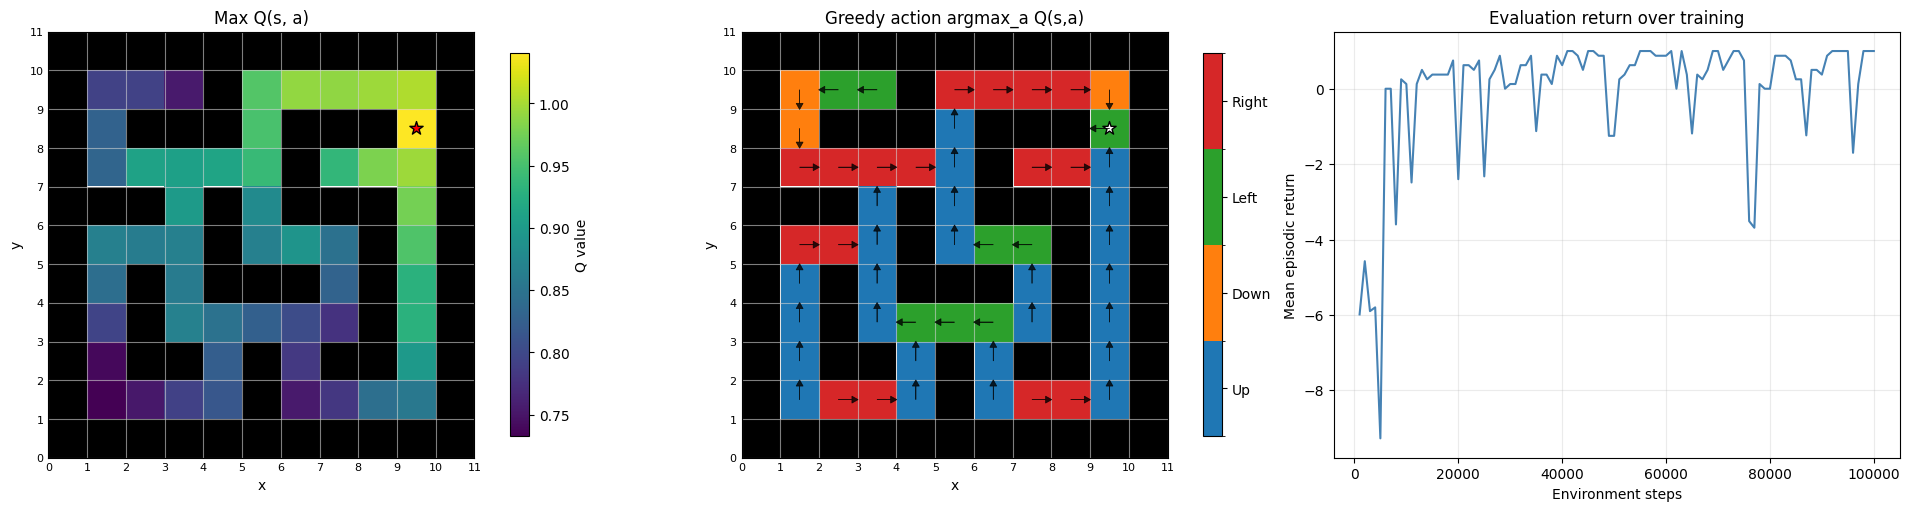

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [2.9549794 2.821733  2.7053726 2.6870859 2.6706824]
cumulative variance (first 5 dims): [0.04258868 0.08142313 0.11712077 0.15233745 0.18712547]
cos(phi(s,a), psi/task): mean=0.0071, std=0.1261


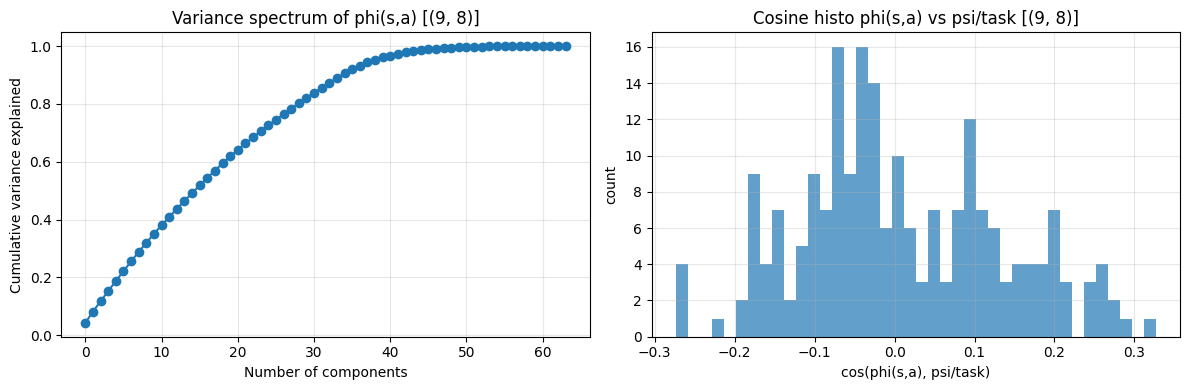


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978      0.971      0.965      0.965      0.950      0.938
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989      0.981      0.977      0.978      0.963      0.952
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997      0.993      0.991      0.991      0.979      0.971
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998      0.994      0.992      0.994      0.983      0.976
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999      0.995      0.992      0.992      0.980      0.974
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000      0.997      0.994      0.993      0.980      0.974
  (3, 6)      0.971      0.981      0.993      0.994    

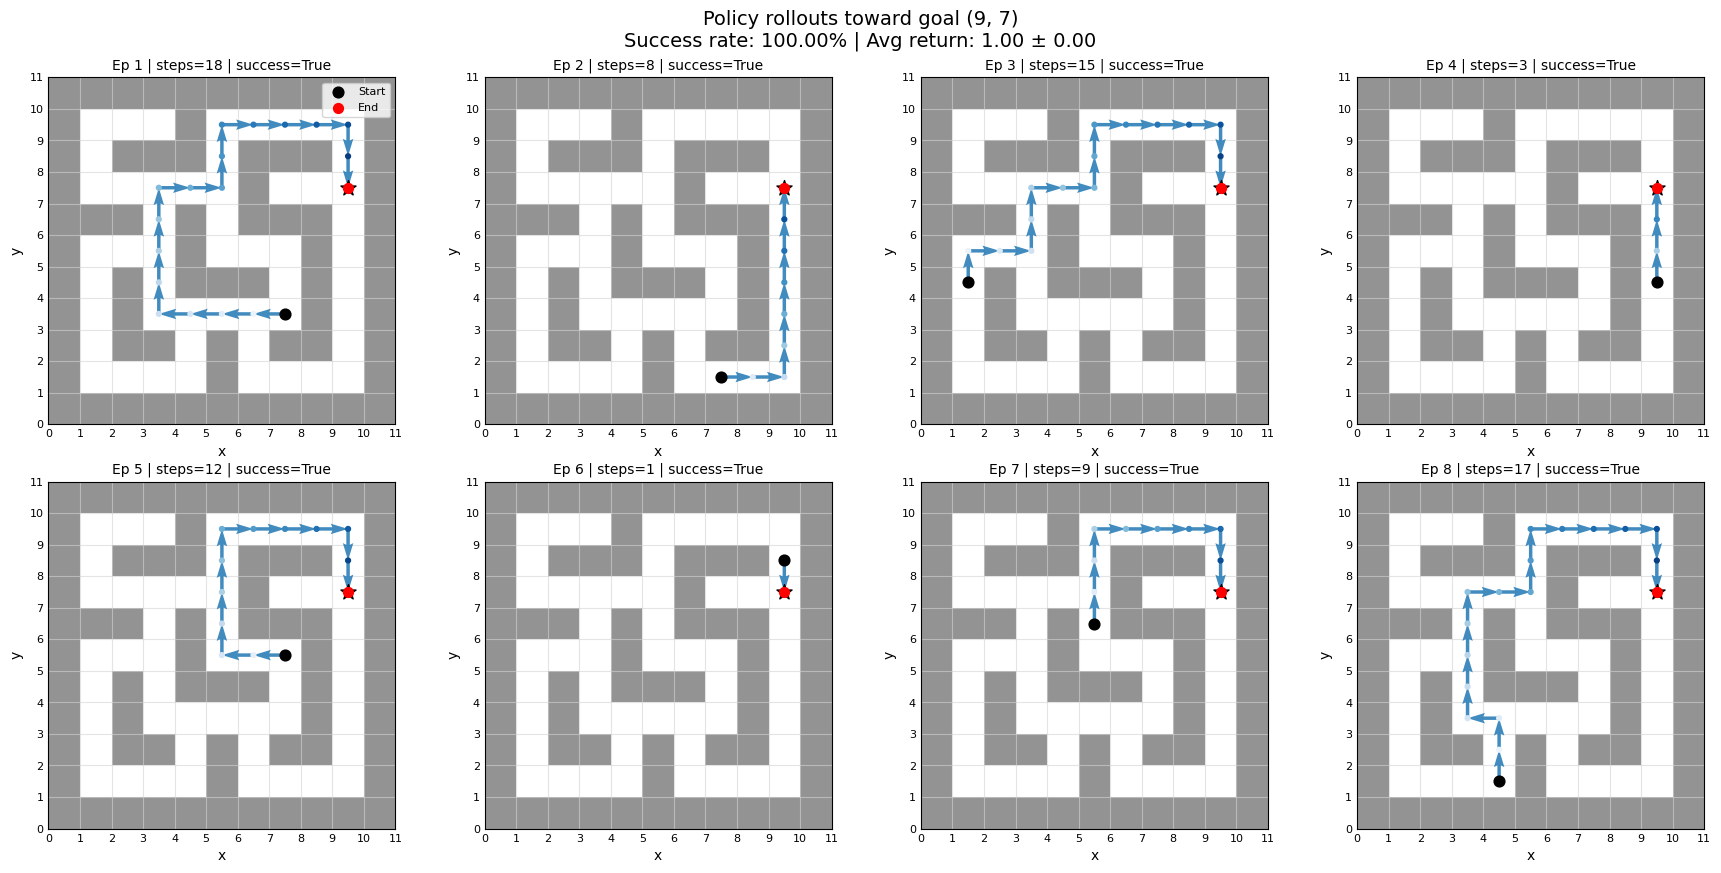

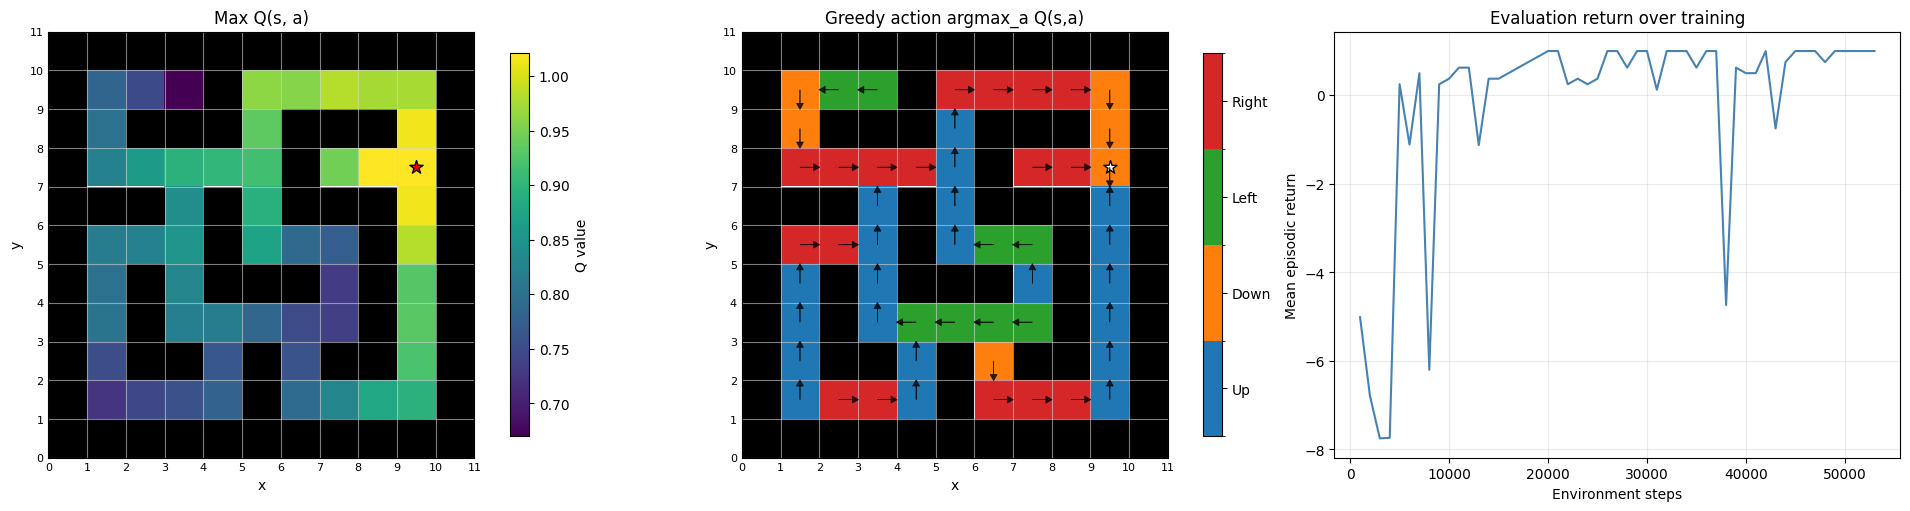

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [2.8434148 2.7733898 2.7202992 2.6965547 2.687937 ]
cumulative variance (first 5 dims): [0.03935306 0.07679168 0.11281066 0.14820358 0.18337065]
cos(phi(s,a), psi/task): mean=-0.0012, std=0.1218


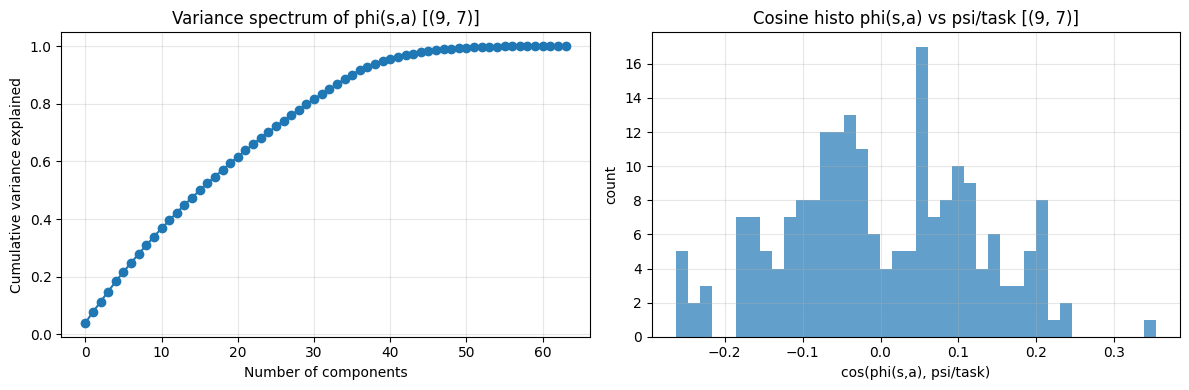


Goal embedding cosine similarity matrix:
     (9, 9)     (1, 1)     (7, 7)     (3, 5)     (3, 9)     (5, 5)     (3, 6)     (9, 1)     (1, 1)     (7, 4)     (9, 8)     (9, 7)
  (9, 9)      1.000      0.993      0.989      0.984      0.977      0.978      0.971      0.965      0.965      0.950      0.938      0.941
  (1, 1)      0.993      1.000      0.996      0.994      0.989      0.989      0.981      0.977      0.978      0.963      0.952      0.954
  (7, 7)      0.989      0.996      1.000      0.999      0.995      0.997      0.993      0.991      0.991      0.979      0.971      0.972
  (3, 5)      0.984      0.994      0.999      1.000      0.998      0.998      0.994      0.992      0.994      0.983      0.976      0.978
  (3, 9)      0.977      0.989      0.995      0.998      1.000      0.999      0.995      0.992      0.992      0.980      0.974      0.975
  (5, 5)      0.978      0.989      0.997      0.998      0.999      1.000      0.997      0.994      0.993      0.980  

In [ ]:
SEEDS = [42]
GOALS = [(9, 9), (1, 1), (7, 7), (3, 5), (3, 9), (5, 5), (3, 6), (9, 1), (1, 1), (7, 4), (9, 8), (9, 7)]
BUFFER_CAPACITY = 100000
LR = float(1e-3)

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder", "q_head"]

overall_results = {
    goal: {
        "eval_returns": [],
        "eval_returns_time": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
    }
    for goal in GOALS
}

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")
    set_seed(seed)

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    q_net_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
        q_hidden_dim=128,
        normalize_embeddings=True,
    ).to(DEVICE)

    q_target_base = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=128,
        rep_dim=64,
        q_hidden_dim=128,
        normalize_embeddings=True,
    ).to(DEVICE)

    next_state_encoder = NextStateEncoder(
        obs_dim=obs_dim,
        hidden_dim=128,
        rep_dim=64,
    ).to(DEVICE)

    seed_task_embedding_memory = []
    seen_goal_labels = []
    weight_history = []
    prev_q_net = None
    prev_q_target = None

    # EWC state for sequential tasks
    ewc_state = EWCState()
    EWC_LAMBDA_SA = 50000.0
    EWC_LAMBDA_NS = 50000.0
    EWC_NUM_BATCHES = 50
    EWC_FISHER_ON = "dynamics"   # or "td"

    for goal_idx, goal in enumerate(GOALS):
        print(f"\n----- seed={seed}, goal={goal} -----\n")

        if goal_idx == 0:
            q_net = deepcopy(q_net_base)
            q_target = deepcopy(q_target_base)
            q_target.load_state_dict(q_net.state_dict())

            for p in q_net.parameters():
                p.requires_grad_(True)

            freeze_sa_encoder = False
            epsilon_reduction = False

        else:
            if prev_q_net is None or prev_q_target is None:
                raise ValueError("Previous Q-networks are not available for transfer learning.")

            q_net = deepcopy(prev_q_net)
            q_target = deepcopy(prev_q_target)
            q_target.load_state_dict(q_net.state_dict())

            for p in q_net.sa_encoder.parameters():
                p.requires_grad_(False)

            # Goal side remains trainable
            for p in q_net.goal_encoder.parameters():
                p.requires_grad_(True)
            if hasattr(q_net, "q_head"):
                for p in q_net.q_head.parameters():
                    p.requires_grad_(True)

            # # If you want psi + last phi layer instead of only psi:
            last_layer = list(q_net.sa_encoder.children())[-1]
            for p in last_layer.parameters():
                p.requires_grad_(True)

            freeze_sa_encoder = False
            epsilon_reduction = False

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_before_train_{goal}",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        use_ewc = goal_idx > 0

        (
            q_network,
            q_target_network,
            next_state_encoder,
            eval_returns,
            eval_returns_time,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_mlp_head_online(
            seed=seed,
            q_network=q_net,
            q_target_network=q_target,
            env=make_env(goal=goal),
            buffer_capacity=BUFFER_CAPACITY,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=100000,
            warmup_steps=5000,
            batch_size=256,
            gamma=0.99,
            tau=0.005,
            eps_start=1.0,
            eps_end=0.05,
            eps_decay_steps=80000,
            train_freq=4,
            goal=goal,
            td_steps=1,
            make_env=make_env,
            epsilon_reduction=False,
            eps_start_transfer=0.2,
            eps_end_transfer=0.05,
            eps_decay_steps_transfer=20000,
            lr_sa=LR,
            lr_ns=LR,
            lr_td=LR,
            next_state_encoder=next_state_encoder,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            freeze_sa_encoder=freeze_sa_encoder,
            ewc_state=ewc_state,
            ewc_lambda_sa=EWC_LAMBDA_SA if use_ewc else 0.0,
            ewc_lambda_ns=EWC_LAMBDA_NS if use_ewc else 0.0,
            enable_early_stop=True,
        )

        # Build Fisher / anchors from the just-finished task for the next task
        ref_params_sa, fisher_sa, ref_params_ns, fisher_ns = compute_ewc_fisher_for_task(
            q_network=q_network,
            next_state_encoder=next_state_encoder,
            replay_buffer=buffer,
            goal=goal,
            num_actions=num_actions,
            device=DEVICE,
            num_batches=EWC_NUM_BATCHES,
            batch_size=256,
            gamma=0.99,
            temperature=0.05,
            contrastive_reg_coef=0.0,
            sigreg_coef=0.01,
            dyn_coef=1.0,
            fisher_on=EWC_FISHER_ON,
        )

        ewc_state.ref_params_sa = ref_params_sa
        ewc_state.fisher_sa = fisher_sa
        ewc_state.ref_params_ns = ref_params_ns
        ewc_state.fisher_ns = fisher_ns

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_network,
                goal_label=goal,
                stage_label=f"goal_{goal_idx}_after_train_{goal}",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        before_snap = weight_history[-2]
        after_snap = weight_history[-1]

        sa_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="sa",
        )

        goal_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="goal",
        )

        print(
            f"[SA drift] goal={goal} | "
            f"L2={sa_change_stats['sample_l2']:.6f} | "
            f"L1={sa_change_stats['sample_l1']:.6f} | "
            f"Linf={sa_change_stats['sample_linf']:.6f} | "
            f"mean|Δ|={sa_change_stats['sample_mean_abs']:.6e} | "
            f"rms={sa_change_stats['sample_rms']:.6e} | "
            f"Δmean={sa_change_stats['stats_delta']['delta_mean']:.6e} | "
            f"Δstd={sa_change_stats['stats_delta']['delta_std']:.6e} | "
            f"Δp50={sa_change_stats['stats_delta']['delta_p50']:.6e}"
        )

        print(
            f"[Goal drift] goal={goal} | "
            f"L2={goal_change_stats['sample_l2']:.6f} | "
            f"L1={goal_change_stats['sample_l1']:.6f} | "
            f"Linf={goal_change_stats['sample_linf']:.6f} | "
            f"mean|Δ|={goal_change_stats['sample_mean_abs']:.6e} | "
            f"rms={goal_change_stats['sample_rms']:.6e} | "
            f"Δmean={goal_change_stats['stats_delta']['delta_mean']:.6e} | "
            f"Δstd={goal_change_stats['stats_delta']['delta_std']:.6e} | "
            f"Δp50={goal_change_stats['stats_delta']['delta_p50']:.6e}"
        )

        visualise_q_table(
            goal,
            q_network,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_network,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )

        seed_task_embedding_memory.append(task_embedding)
        seen_goal_labels.append(str(goal))
        print_goal_embedding_similarity(
            seed_task_embedding_memory,
            goal_labels=seen_goal_labels,
        )

        prev_q_net = deepcopy(q_network)
        prev_q_target = deepcopy(q_target_network)

        overall_results[goal]["eval_returns"].append(eval_returns)
        overall_results[goal]["eval_returns_time"].append(eval_returns_time)
        overall_results[goal]["min_steps"].append(min_steps)
        overall_results[goal]["min_time"].append(min_time)
        overall_results[goal]["task_embeddings"].append(task_embedding)
        overall_results[goal]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[goal]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[goal]["sa_batches_final"].append(sa_batch_final)
        overall_results[goal]["sa_weight_change"].append(sa_change_stats)
        overall_results[goal]["goal_weight_change"].append(goal_change_stats)

[WARN] Skipping goal (9, 9): no valid results
[WARN] Skipping goal (1, 1): no valid results
[WARN] Skipping goal (3, 6): no valid results
[WARN] Skipping goal (7, 4): no valid results
[WARN] Skipping goal (9, 8): no valid results


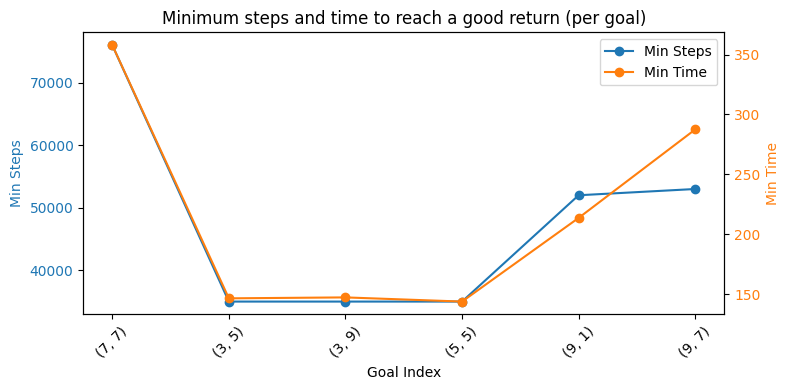

In [7]:
goals = list(overall_results.keys())

min_steps_per_goal = []
min_time_per_goal = []
used_goals = []

for goal in goals:
    steps_raw = overall_results[goal]["min_steps"]
    time_raw  = overall_results[goal]["min_time"]

    steps_arr = np.array(steps_raw).flatten()
    time_arr  = np.array(time_raw).flatten()

    # Skip goals with no data
    if steps_arr.size == 0 or time_arr.size == 0:
        print(f"[WARN] Skipping goal {goal}: empty min_steps or min_time")
        continue

    steps_arr = np.array([np.nan if x is None else x for x in steps_arr], dtype=float)
    time_arr  = np.array([np.nan if x is None else x for x in time_arr], dtype=float)

    if np.all(np.isnan(steps_arr)) or np.all(np.isnan(time_arr)):
        print(f"[WARN] Skipping goal {goal}: no valid results")
        continue


    min_steps_per_goal.append(steps_arr.min())
    min_time_per_goal.append(time_arr.min())
    used_goals.append(goal)

if not min_steps_per_goal:
    raise ValueError("No goals with non-empty min_steps/min_time found.")

x = np.arange(len(used_goals))

fig, ax1 = plt.subplots(figsize=(8,4))

ax1.set_title("Minimum steps and time to reach a good return (per goal)")

# Left y-axis: min steps
line1 = ax1.plot(
    x, min_steps_per_goal,
    label="Min Steps",
    color="tab:blue",
    marker="o",
)
ax1.set_xlabel("Goal Index")
ax1.set_ylabel("Min Steps", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: min time
ax2 = ax1.twinx()
line2 = ax2.plot(
    x, min_time_per_goal,
    label="Min Time",
    color="tab:orange",
    marker="o",
)
ax2.set_ylabel("Min Time", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Label x-axis with actual goal IDs
ax1.set_xticks(x)
ax1.set_xticklabels([str(g) for g in used_goals], rotation=45)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="best")

fig.tight_layout()
plt.show()

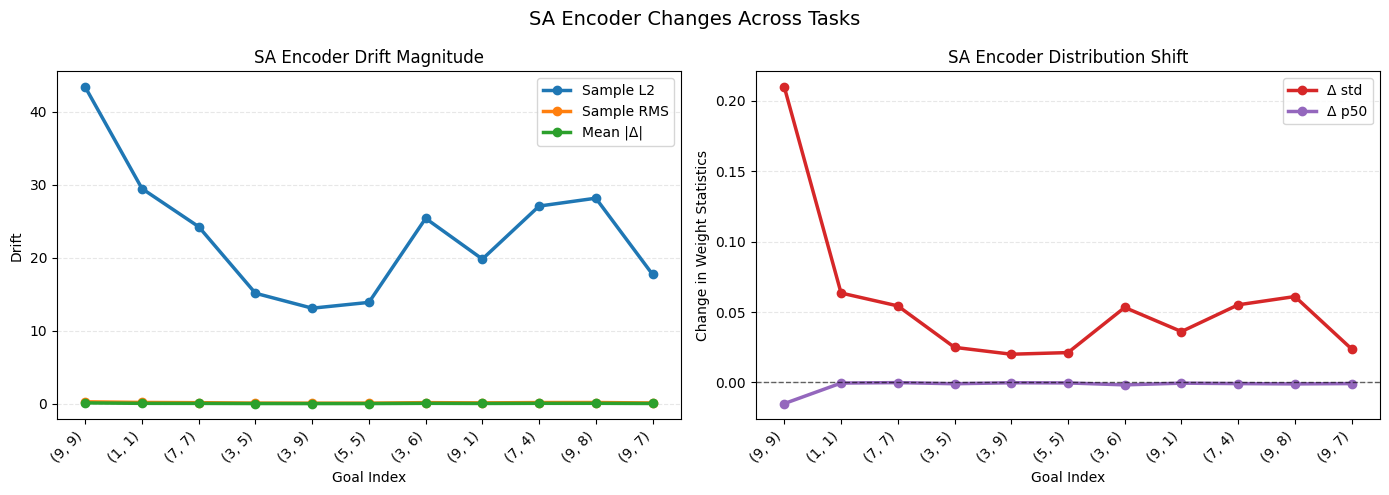

In [8]:
plot_sa_encoder_changes_across_tasks(overall_results)

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

(9, 9) cos(old, final) = 0.9406751394271851
(1, 1) cos(old, final) = 0.9540916681289673
(7, 7) cos(old, final) = 0.9724364280700684
(3, 5) cos(old, final) = 0.9776257276535034
(3, 9) cos(old, final) = 0.9753045439720154
(5, 5) cos(old, final) = 0.9751402139663696
(3, 6) cos(old, final) = 0.9784837961196899
(9, 1) cos(old, final) = 0.9878072738647461
(7, 4) cos(old, final) = 0.9991122484207153
(9, 8) cos(old, final) = 0.9997235536575317
(9, 7) cos(old, final) = 1.0
Episode 1: 100 steps | return: -9.80 | reached goal: False
Episode 2: 100 steps | return: -9.90 | reached goal: False
Episode 3: 100 steps | return: -10.00 | reached goal: False


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/src/visualisations.py:1203: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  task_embedding = torch.tensor(task_embedding, dtype=torch.float32, device=device)


Episode 4: 100 steps | return: -10.00 | reached goal: False
Episode 5: 100 steps | return: -9.90 | reached goal: False
Episode 6: 1 steps | return: 1.00 | reached goal: True
Episode 7: 100 steps | return: -10.00 | reached goal: False
Episode 8: 100 steps | return: -9.80 | reached goal: False

Success rate: 12.50% over 8 episodes
Average return: -8.55 ± 3.61


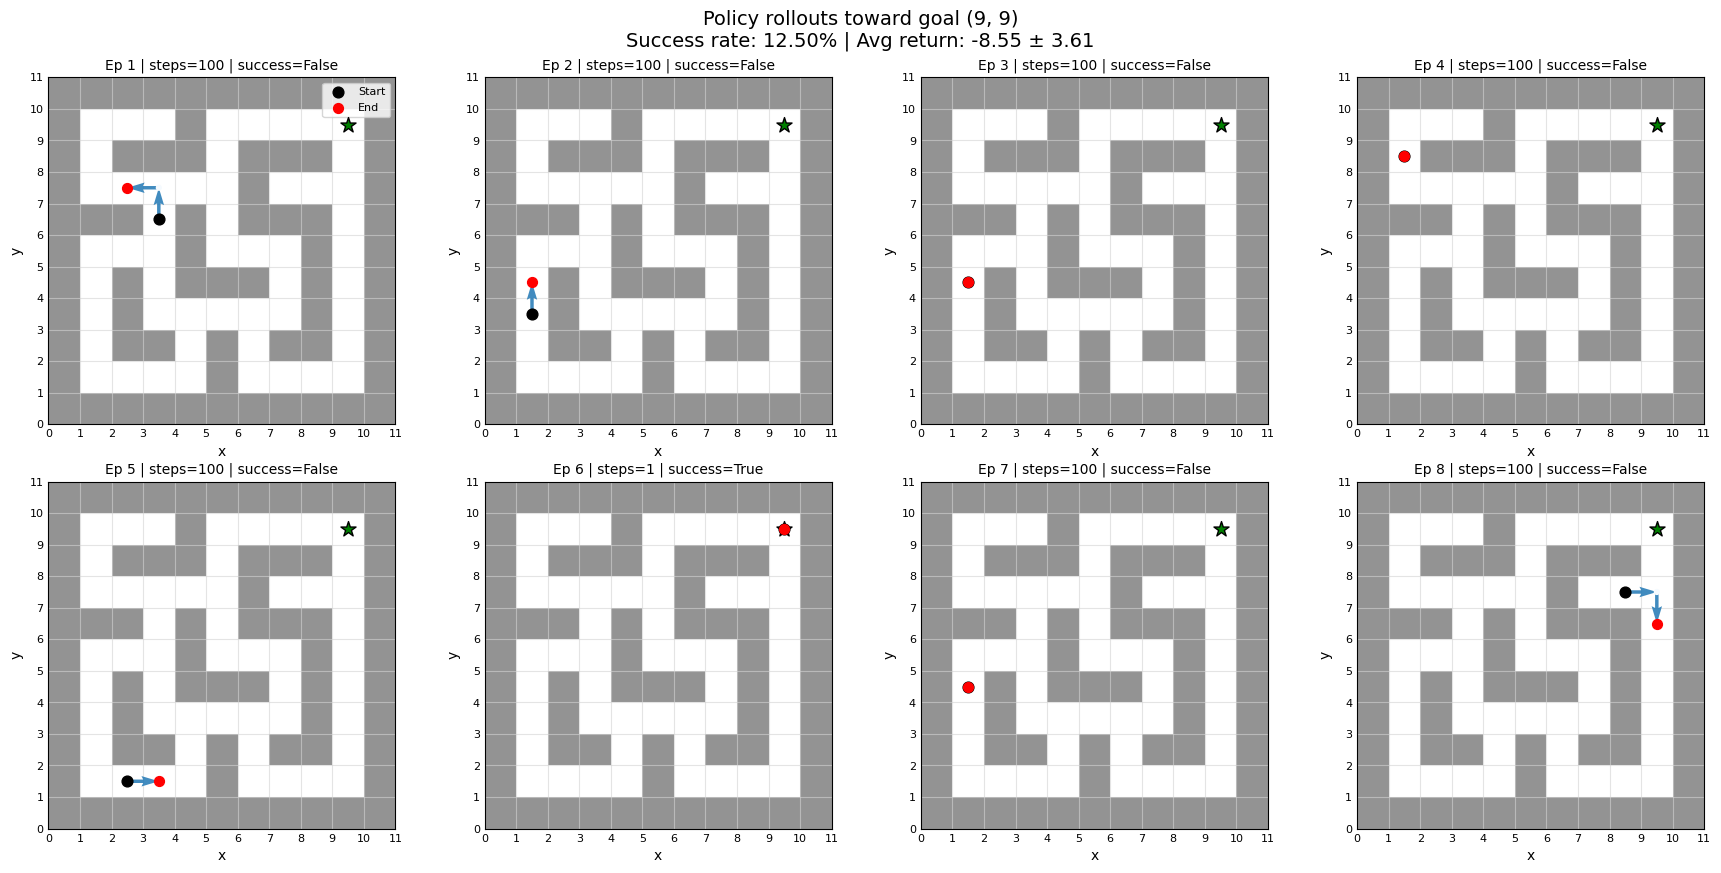

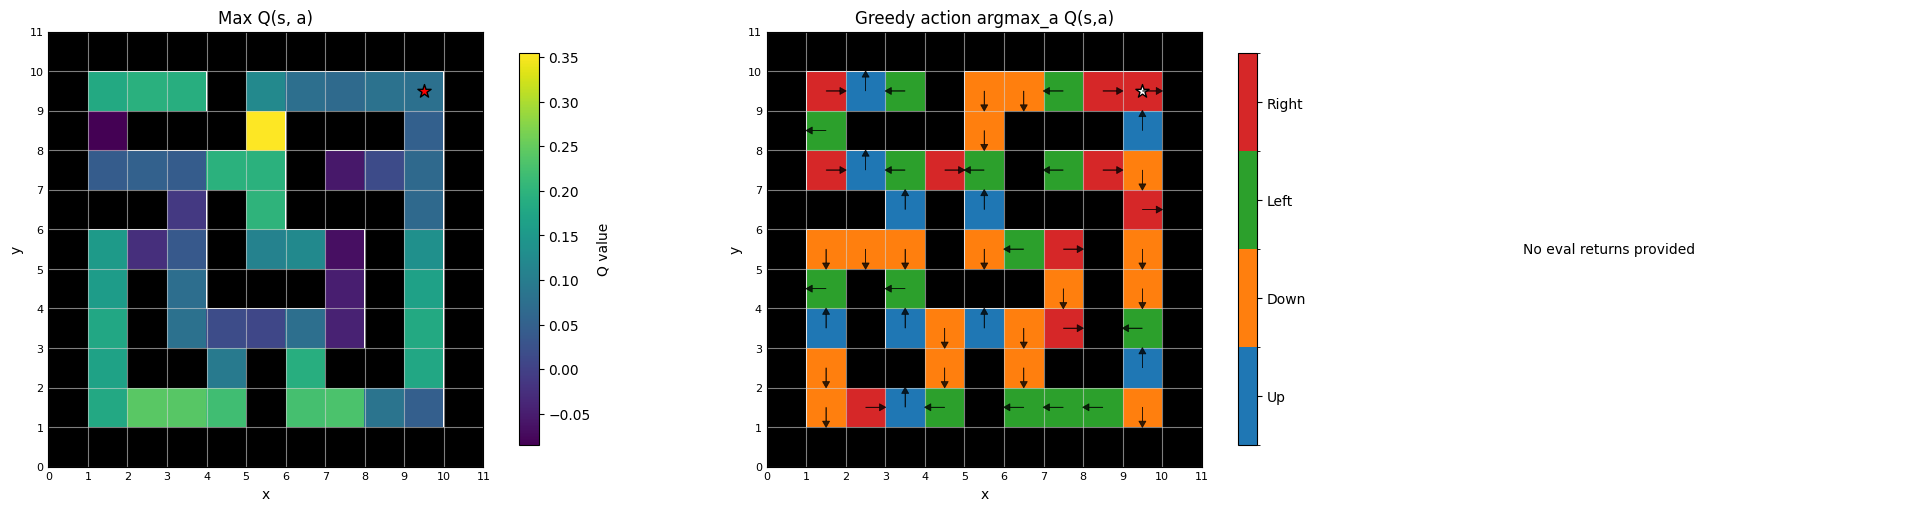

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [2.8434148 2.7733898 2.7202992 2.6965547 2.687937 ]
cumulative variance (first 5 dims): [0.03935306 0.07679168 0.11281066 0.14820358 0.18337065]
cos(phi(s,a), psi/task): mean=-0.0012, std=0.1218


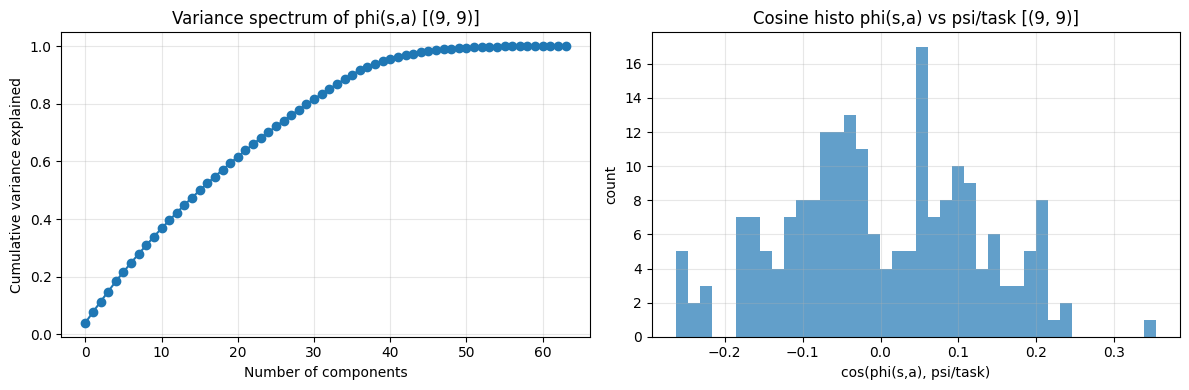

Episode 1: 100 steps | return: -9.90 | reached goal: False
Episode 2: 100 steps | return: -9.90 | reached goal: False
Episode 3: 100 steps | return: -10.00 | reached goal: False
Episode 4: 100 steps | return: -10.00 | reached goal: False
Episode 5: 100 steps | return: -10.00 | reached goal: False
Episode 6: 100 steps | return: -10.00 | reached goal: False
Episode 7: 100 steps | return: -10.00 | reached goal: False
Episode 8: 100 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: -8.72 ± 3.30


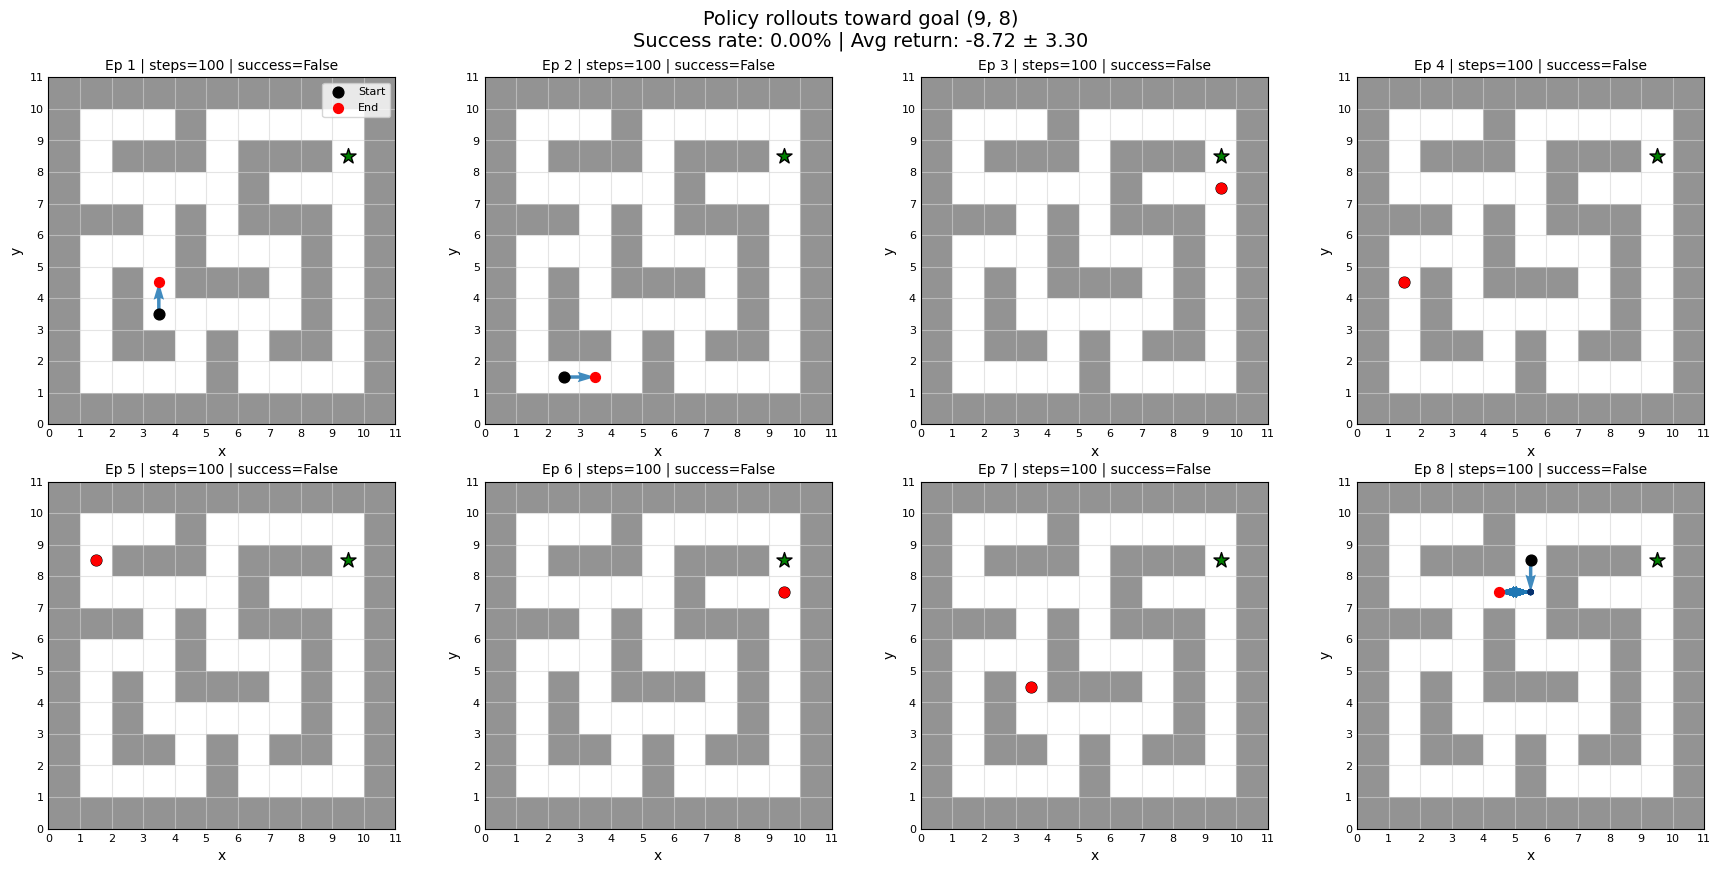

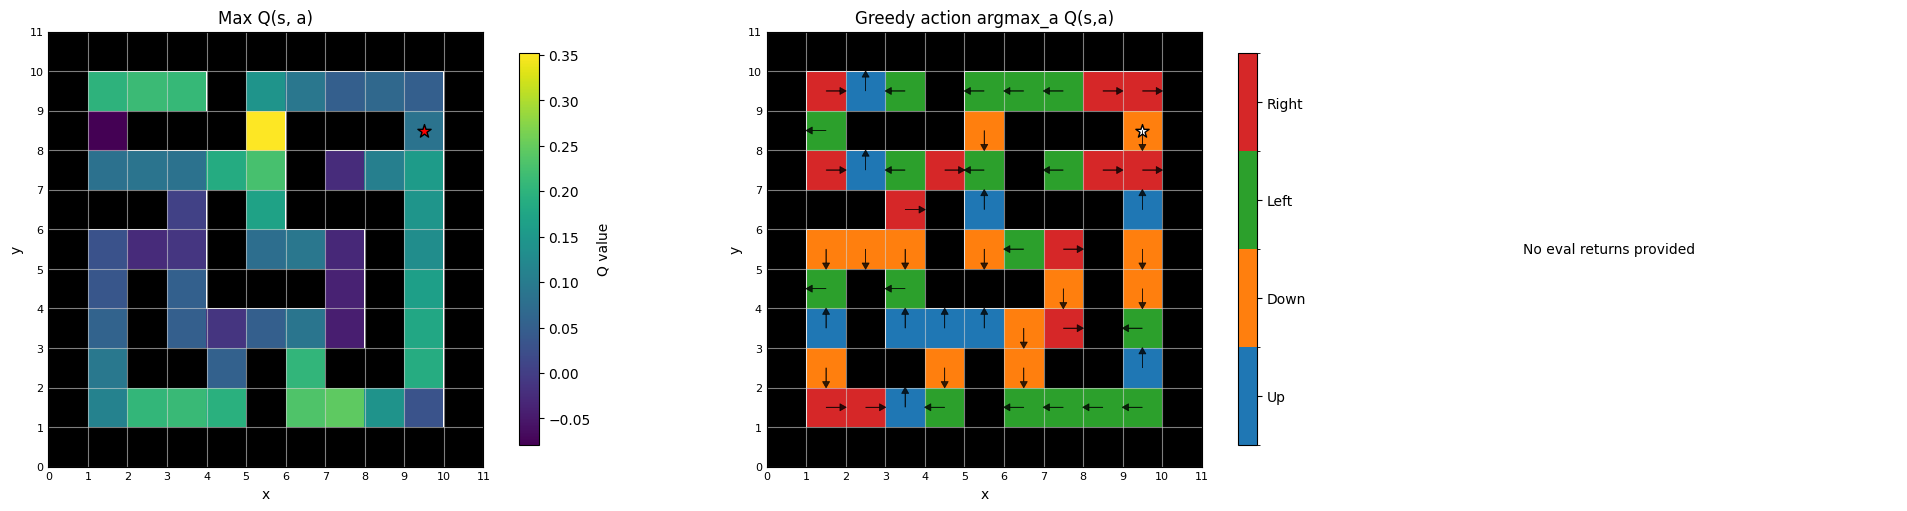

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [2.8434148 2.7733898 2.7202992 2.6965547 2.687937 ]
cumulative variance (first 5 dims): [0.03935306 0.07679168 0.11281066 0.14820358 0.18337065]
cos(phi(s,a), psi/task): mean=-0.0012, std=0.1218


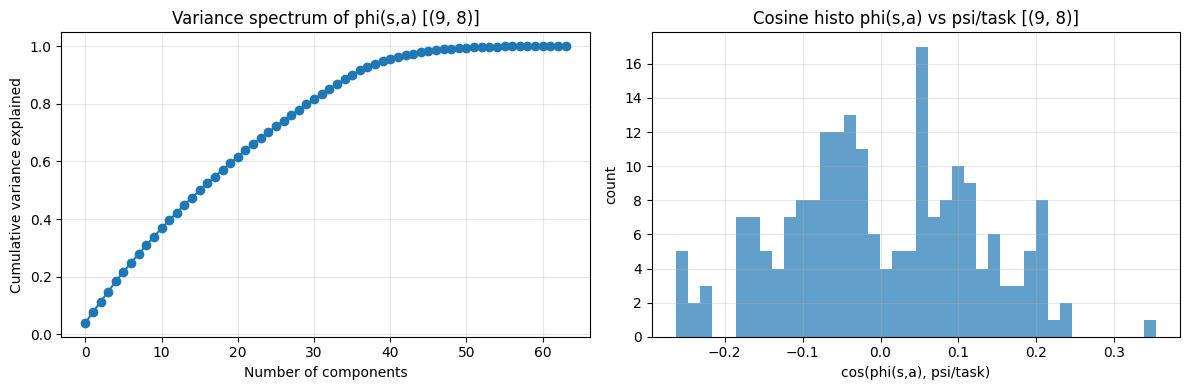

Episode 1: 100 steps | return: -10.00 | reached goal: False
Episode 2: 100 steps | return: -10.00 | reached goal: False
Episode 3: 100 steps | return: -9.90 | reached goal: False
Episode 4: 1 steps | return: 1.00 | reached goal: True
Episode 5: 100 steps | return: -10.00 | reached goal: False
Episode 6: 100 steps | return: -10.00 | reached goal: False
Episode 7: 100 steps | return: -10.00 | reached goal: False
Episode 8: 100 steps | return: -9.80 | reached goal: False

Success rate: 12.50% over 8 episodes
Average return: -8.59 ± 3.62


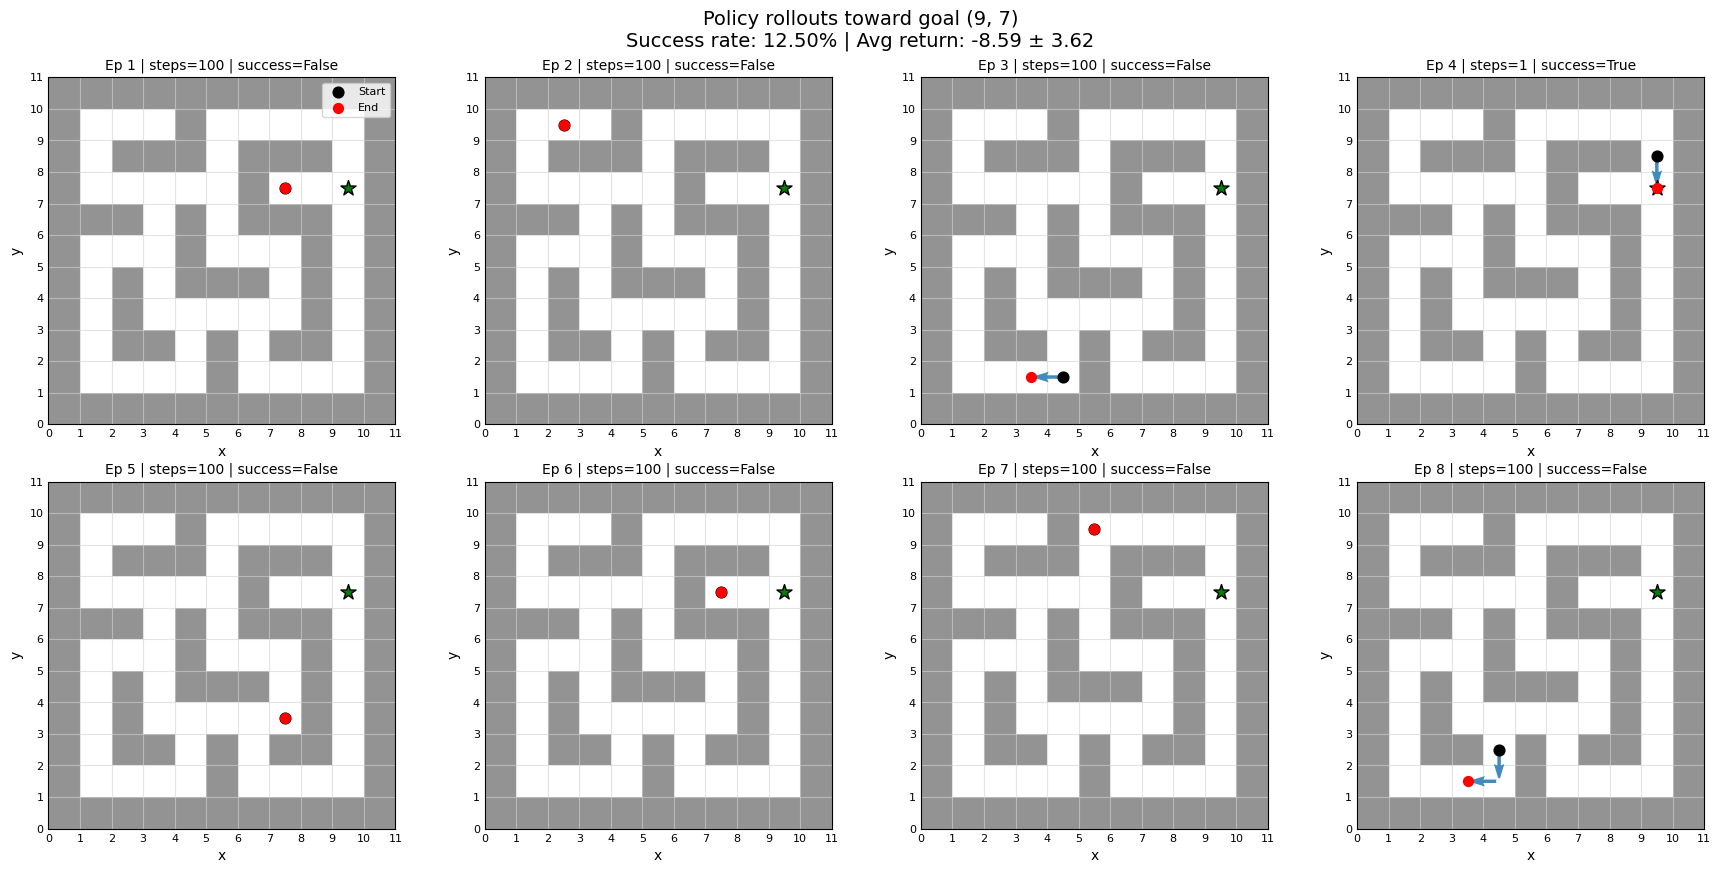

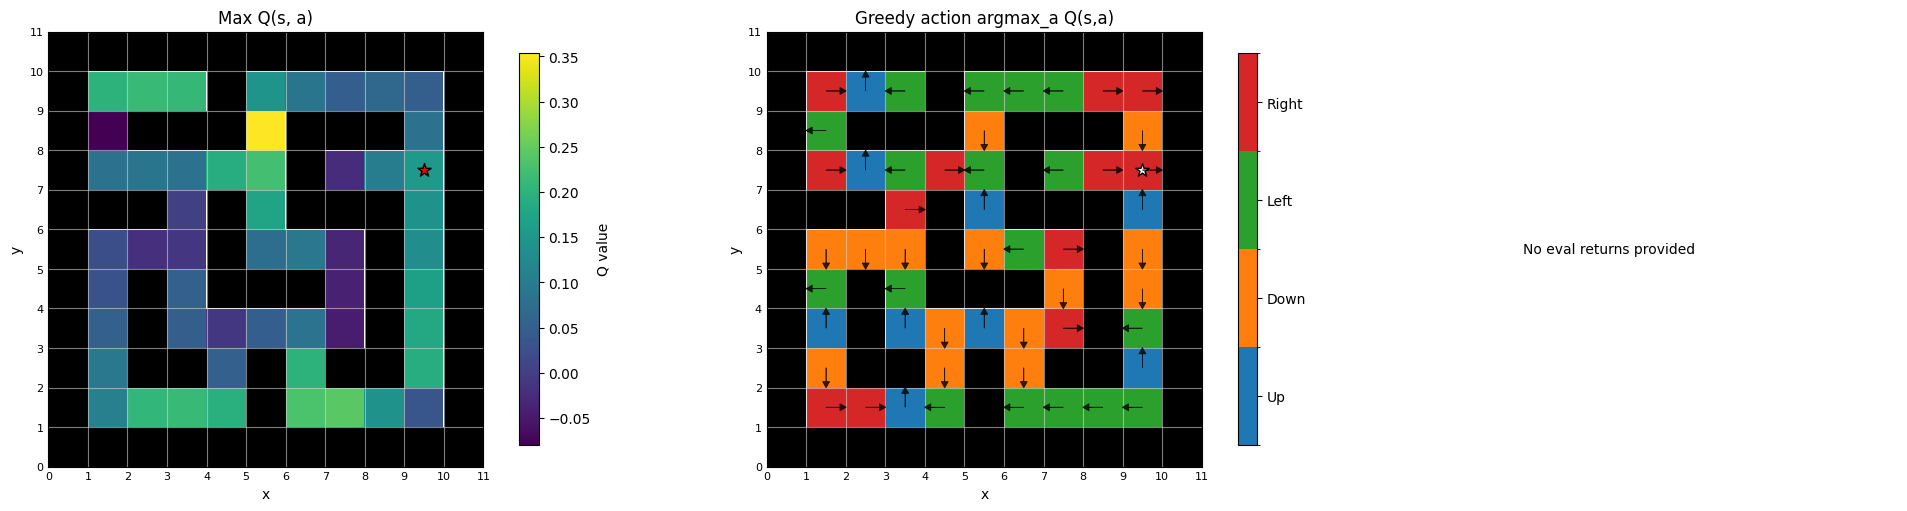

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 64)
psi(z) / task code base: (1, 64)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [2.8434148 2.7733898 2.7202992 2.6965547 2.687937 ]
cumulative variance (first 5 dims): [0.03935306 0.07679168 0.11281066 0.14820358 0.18337065]
cos(phi(s,a), psi/task): mean=-0.0012, std=0.1218


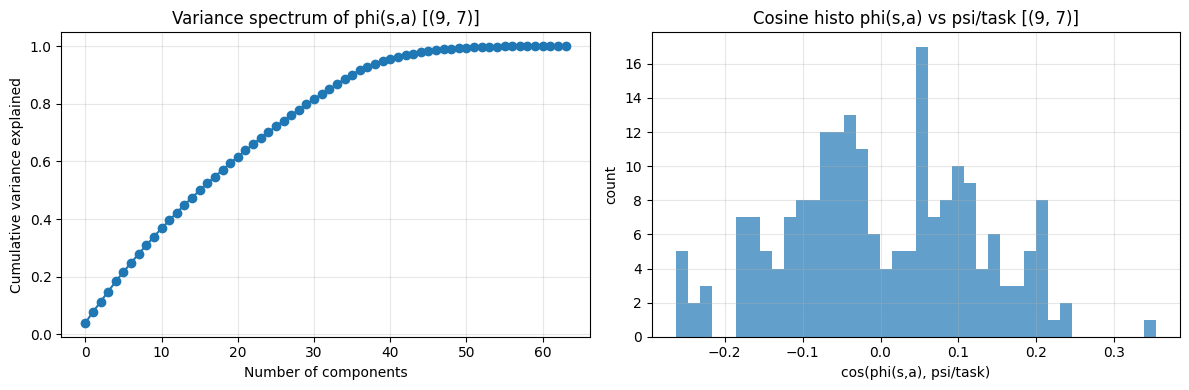

In [9]:
GOALS = [(9, 9), (9,8), (9,7)]

drift = compute_embedding_drift(overall_results, q_network, DEVICE)
for goal, cos in drift.items():
    print(goal, "cos(old, final) =", cos)

for goal in GOALS:

    if goal not in overall_results:
        task_embedding = q_network.encode_goal(torch.tensor(goal, dtype=torch.float32, device=DEVICE).unsqueeze(0)).detach().cpu().numpy()
    else:
        task_embedding = overall_results[goal]["task_embeddings"]
    visualise_q_table(goal, q_network, eval_returns=None, task_embedding=task_embedding, device=DEVICE, make_env=make_env)
    visualise_embeddings(goal, q_network, device=DEVICE, make_env=make_env)

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_2d_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])

(9, 9)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(1, 1)
task_embeddings: 2
sa_fixed_probe_embeddings: 2
sa_batches_final: 2
(7, 7)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(3, 5)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(3, 9)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(5, 5)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(3, 6)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(9, 1)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(7, 4)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(9, 8)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
(9, 7)
task_embeddings: 1
sa_fixed_probe_embeddings: 1
sa_batches_final: 1
plots/full_embedding_dashboard_maze.html
{'trace': 0.9999520024531712, 'mean_diag': 0.0156242500383308, 'mean_abs_offdiag': 0.0013560522688717998, 'eig_ratio': 105.97775829063